# ARTIFEX v2 — FIXED Training Notebook

## Changes in this version (all bugs fixed):

1. **MPS memory**: `PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0` enabled (full 16GB unified memory)
2. **GAN was disabled**: `lambda_adv_global/local` were 0.0 — fixed to 0.5 each
3. **Style loss disabled**: `lambda_style` was 0.0 — fixed to 100.0
4. **Discriminator LR too low**: `lr_d` was 0.00005 — fixed to 0.0001 (same as G)
5. **Batch size**: increased from 2 to 4 (safe with memory fix above)
6. **torch.compile**: added to G and both Ds for ~30% MPS speedup
7. **Gradient clipping**: `clip_grad_norm_(max_norm=1.0)` added after every backward
8. **Resume was broken**: `load_state_dict` calls were missing — fixed
9. **Empty if block**: syntax issue in training loop fixed

## Run order:
1. Cells 1-4: Setup + config
2. Cell 5: H5 verification
3. Cells 6-7: Dataset + sanity check
4. Cells 8-11: Model architecture
5. Cell 12-13: Loss functions
6. Cells 14-15: Training functions
7. Cell 16: START TRAINING

## Ablation order:
`baseline` → `dir_only` → `edge_only` → `hist_only` → `full`

Use `run_ablation()` from Cell 26 — do NOT manually edit CONFIG between runs.


In [1]:

# ============================================================================
# M2 SETTINGS (CLEAN: no per-step sync / no CPU fallback)
# ============================================================================
import os
import torch

# IMPORTANT:
# - Turn fallback OFF so you don't silently run slow CPU ops.
# - Do NOT call torch.mps.synchronize() in the training loop.
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '0'
# Optional: allow PyTorch to use more of unified memory (keep default if unsure)
os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'  # Use full unified memory on M2

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

def clear_mps_cache():
    """Only use if you hit an OOM. Do NOT call every batch."""
    if device.type == 'mps':
        torch.mps.empty_cache()


Using device: mps


In [2]:

# ============================================================================
# FULL IMPLEMENTATION WITH BRUSHSTROKE-AWARE LOSSES
# ============================================================================
# 1. IMPORTS
# ============================================================================
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import h5py
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# 'device' is defined in Cell 1
print(f"Using device: {device}")


Using device: mps


In [3]:
import sys
print(sys.executable)


/Library/Frameworks/Python.framework/Versions/3.12/bin/python3


In [4]:
# ============================================================================
# 2. CONFIGURATION — FIXED VERSION
#    Changes from original:
#      - lambda_adv_global/local: 0.0 -> 0.5  (GAN was disabled, causing blurry outputs)
#      - lambda_style: 0.0 -> 100.0            (style loss was disabled)
#      - lr_d: 0.00005 -> 0.0001               (D was too slow, G fooled it trivially)
#      - batch_size: 2 -> 4                    (safe with HIGH_WATERMARK_RATIO=0.0)
#    See Cell 1 for MPS memory fix.
# ============================================================================
# 2. CONFIGURATION — with reproducibility, timestamped runs, ablation support
#    (updated for artifex_v2 .h5 + live history saving)
# ============================================================================

import random, datetime

# ---- Reproducibility seeds ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Seeds set to {SEED}")

# ---- Timestamped run folder ----
RUN_TAG = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# ---- Ablation presets ----
ABLATION_CONFIGS = {
    'baseline':  {'lambda_direction': 0.0, 'lambda_thickness': 0.0, 'lambda_histogram': 0.0},
    'dir_only':  {'lambda_direction': 2.0, 'lambda_thickness': 0.0, 'lambda_histogram': 0.0},
    'edge_only': {'lambda_direction': 0.0, 'lambda_thickness': 1.0, 'lambda_histogram': 0.0},
    'hist_only': {'lambda_direction': 0.0, 'lambda_thickness': 0.0, 'lambda_histogram': 1.0},
    'full':      {'lambda_direction': 2.0, 'lambda_thickness': 1.0, 'lambda_histogram': 1.0},
}

# ---- Choose ablation ----
ABLATION = 'baseline'  # Change to: 'dir_only', 'edge_only', 'hist_only', 'full'

from pathlib import Path

# ---- ONE PLACE TO EDIT PATHS ----
# Set this to your local ARTIFEX implementation folder on your M2 Mac.
PROJECT_ROOT = Path("/Users/althafali/Downloads/ARTIFEX/implementation").expanduser()

DATA_ROOT = PROJECT_ROOT / "data" / "processed"
RUNS_ROOT = PROJECT_ROOT / "runs"
BRUSHSTROKE_H5 = PROJECT_ROOT / "brushstroke_features.h5"
VGG_WEIGHTS = PROJECT_ROOT / "models" / "saved_models" / "vgg19-dcbb9e9d.pth"
BASELINE_CKPT = PROJECT_ROOT / "models" / "baseline" / "baseline_best.pth"

CONFIG = {
    # Paths
    'train_original_dir': str(DATA_ROOT / "train" / "original"),
    'train_masked_dir':   str(DATA_ROOT / "train" / "masked"),
    'train_masks_dir':    str(DATA_ROOT / "train" / "masks"),

    'val_original_dir':   str(DATA_ROOT / "val" / "original"),
    'val_masked_dir':     str(DATA_ROOT / "val" / "masked"),
    'val_masks_dir':      str(DATA_ROOT / "val" / "masks"),

    'test_original_dir':  str(DATA_ROOT / "test" / "original"),
    'test_masked_dir':    str(DATA_ROOT / "test" / "masked"),
    'test_masks_dir':     str(DATA_ROOT / "test" / "masks"),

    # IMPORTANT: point this to the .h5 generated by artifex_v2.ipynb
    'brushstroke_h5': str(BRUSHSTROKE_H5),

    # VGG weights (optional; if missing, torchvision will download)
    'vgg_weights': str(VGG_WEIGHTS),

    # Run-specific output dirs (timestamped)
    'checkpoint_dir': str(RUNS_ROOT / f"{ABLATION}_{RUN_TAG}" / "checkpoints"),
    'log_dir':        str(RUNS_ROOT / f"{ABLATION}_{RUN_TAG}" / "logs"),
    'output_dir':     str(RUNS_ROOT / f"{ABLATION}_{RUN_TAG}" / "outputs"),

    # Training
    'epochs': 100,
    # On M2, start with 2. If you don't OOM, try 4.
    'batch_size': 4,
    'lr_g': 0.0001,
    'lr_d': 0.0001,
    'beta1': 0.5,
    'beta2': 0.999,

    # Loss weights - standard
    'lambda_l1': 10.0,
    'lambda_perceptual': 0.1,
    'lambda_style': 100.0,
    'lambda_adv_global': 0.5,
    'lambda_adv_local': 0.5,

    # Loss weights - brushstroke (overridden by ablation preset below)
    'lambda_direction': 2.0,
    'lambda_thickness': 1.0,   # = edge_strength proxy loss in your v2 pipeline
    'lambda_histogram': 1.0,

    # Model metadata
    'model_type': ABLATION,
    'seed': SEED,
    'run_tag': RUN_TAG,

    # Resume training
    'resume_from_checkpoint': False,
    'checkpoint_path': str(BASELINE_CKPT),

    # Saving
    'save_every': 5,
    'image_size': 512,

    # H5 / dataset behavior
    'cache_h5_in_ram': False,

    # Live training history (saved every epoch, survives interrupts)
    'save_history_every_epoch': True,
}

# Apply ablation preset
for k, v in ABLATION_CONFIGS[ABLATION].items():
    CONFIG[k] = v

# Create run directories
for d in [CONFIG['checkpoint_dir'], CONFIG['log_dir'], CONFIG['output_dir']]:
    os.makedirs(d, exist_ok=True)

# History/log file paths (derived after log_dir exists)
CONFIG['history_live_json']  = os.path.join(CONFIG['log_dir'], 'training_history_live.json')
CONFIG['history_final_json'] = os.path.join(CONFIG['log_dir'], 'training_history_final.json')
CONFIG['history_csv']        = os.path.join(CONFIG['log_dir'], 'training_history_live.csv')
CONFIG['history_plot_png']   = os.path.join(CONFIG['output_dir'], 'training_curves_live.png')
CONFIG['h5_audit_json']      = os.path.join(CONFIG['log_dir'], 'h5_audit_summary.json')
CONFIG['h5_stats_plot_png']  = os.path.join(CONFIG['output_dir'], 'h5_stats_summary.png')
CONFIG['h5_sample_plot_png'] = os.path.join(CONFIG['output_dir'], 'h5_sample_priors.png')

# Quick H5 existence check (full validation + plots runs in next cell)
if not os.path.exists(CONFIG['brushstroke_h5']):
    print('WARNING: brushstroke .h5 not found at CONFIG[\'brushstroke_h5\']')
    print('  Set the correct path to the .h5 generated by artifex_v2.ipynb before continuing.')
else:
    print(f"H5 file found: {CONFIG['brushstroke_h5']}")

# Export split lists for reproducibility
import json as _json
_split_lists = {}
for _split_name, _dir in [('train', CONFIG['train_original_dir']),
                          ('val', CONFIG['val_original_dir']),
                          ('test', CONFIG['test_original_dir'])]:
    if os.path.exists(_dir):
        _split_lists[_split_name] = sorted([f for f in os.listdir(_dir) if f.endswith('.png')])
    else:
        _split_lists[_split_name] = []
        print(f"WARNING: split directory missing: {_dir}")

_split_path = os.path.join(CONFIG['log_dir'], 'split_lists.json')
with open(_split_path, 'w') as _fp:
    _json.dump(_split_lists, _fp, indent=2)
print(f"Split lists saved to: {_split_path}")

# Snapshot config to run folder for reproducibility
config_path = os.path.join(CONFIG['log_dir'], 'config_snapshot.json')
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)

print("Configuration loaded")
print(f"   Ablation: {ABLATION}")
print(f"   Run tag:  {RUN_TAG}")
print(f"   Loss Weights: dir={CONFIG['lambda_direction']}, edge={CONFIG['lambda_thickness']}, hist={CONFIG['lambda_histogram']}")
print(f"   Resume: {CONFIG['resume_from_checkpoint']}")
print(f"   Config snapshot: {config_path}")


Seeds set to 42
H5 file found: /Users/althafali/Downloads/ARTIFEX/implementation/brushstroke_features.h5
Split lists saved to: /Users/althafali/Downloads/ARTIFEX/implementation/runs/baseline_20260226_092117/logs/split_lists.json
Configuration loaded
   Ablation: baseline
   Run tag:  20260226_092117
   Loss Weights: dir=0.0, edge=0.0, hist=0.0
   Resume: False
   Config snapshot: /Users/althafali/Downloads/ARTIFEX/implementation/runs/baseline_20260226_092117/logs/config_snapshot.json


H5 splits found: ['test', 'train', 'val']
[train] H5=1417 | disk=1417 | sampled=120 | key_err=0 | shape_err=0
[val] H5=303 | disk=303 | sampled=120 | key_err=0 | shape_err=0
[test] H5=305 | disk=305 | sampled=120 | key_err=0 | shape_err=0
H5 audit summary saved: /Users/althafali/Downloads/ARTIFEX/implementation/runs/baseline_20260226_092117/logs/h5_audit_summary.json


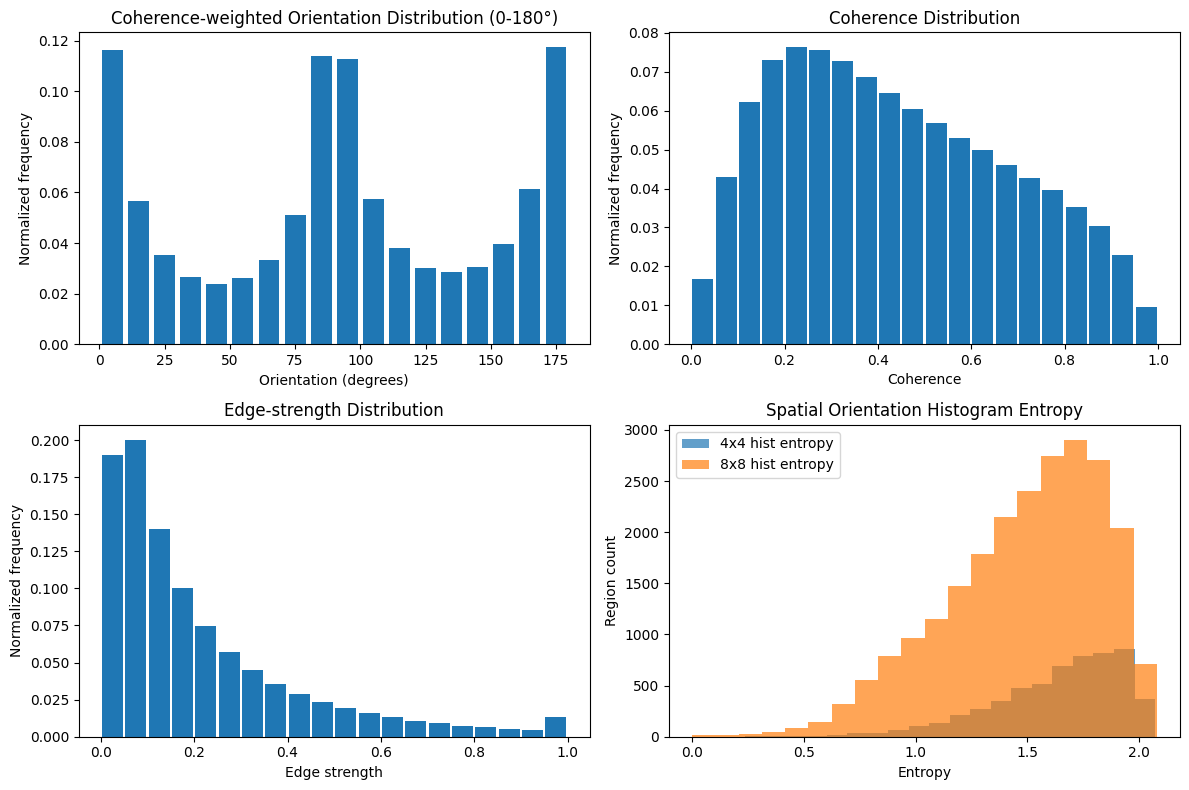

H5 stats plot saved: /Users/althafali/Downloads/ARTIFEX/implementation/runs/baseline_20260226_092117/outputs/h5_stats_summary.png


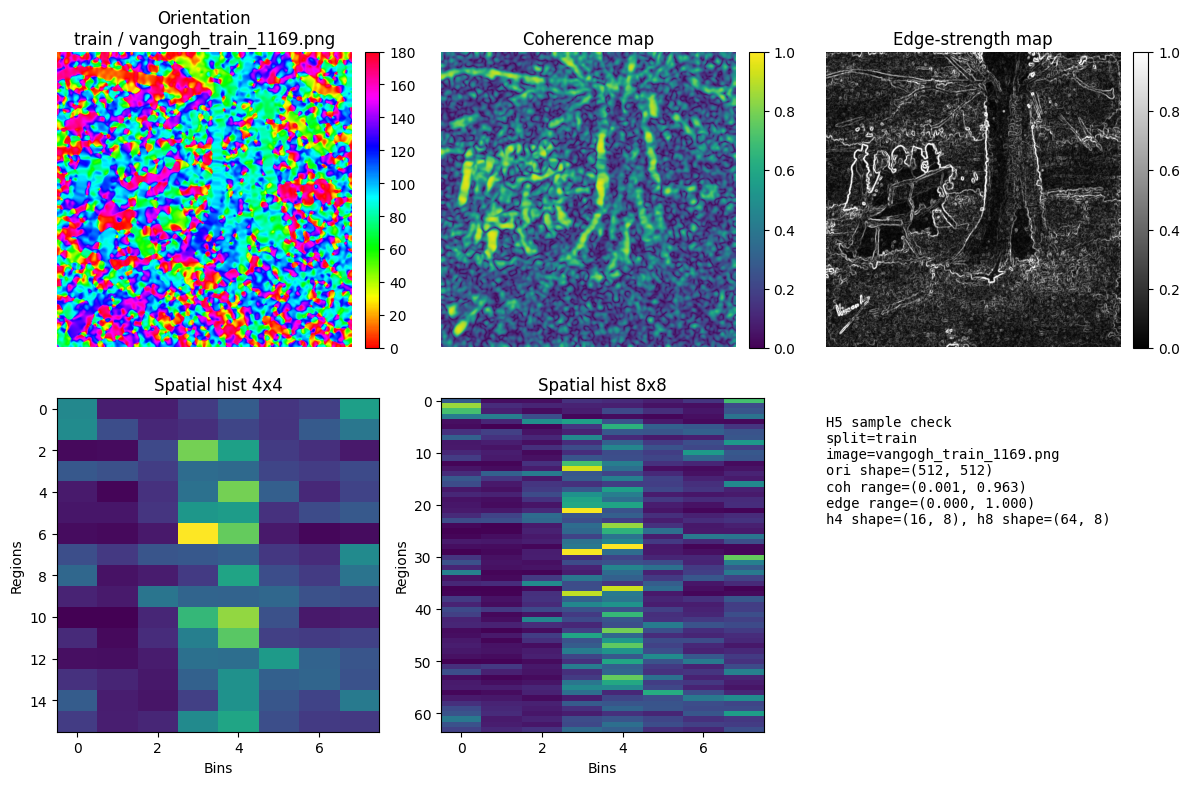

H5 sample priors plot saved: /Users/althafali/Downloads/ARTIFEX/implementation/runs/baseline_20260226_092117/outputs/h5_sample_priors.png


In [5]:
# ============================================================================
# 2B. H5 VERIFICATION + THESIS-USEFUL STATISTICS PLOTS (artifex_v2-compatible)
#     Run this BEFORE training to verify the .h5 and inspect prior distributions
# ============================================================================

import math
import h5py
import matplotlib.pyplot as plt

EXPECTED_H5_KEYS = {
    'orientation_field',
    'coherence_map',
    'edge_strength_map',
    'spatial_hist_4x4',
    'spatial_hist_8x8',
}

def _as_hw(arr, name):
    arr = np.asarray(arr)
    if arr.ndim == 2:
        return arr.astype(np.float32)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        return arr[..., 0].astype(np.float32)
    if arr.ndim == 3 and arr.shape[0] == 1:
        return arr[0].astype(np.float32)
    raise ValueError(f"{name}: unsupported shape {arr.shape}")

def _entropy_rows(hist_2d, eps=1e-8):
    h = np.asarray(hist_2d, dtype=np.float32)
    row_sums = h.sum(axis=1, keepdims=True)
    valid = row_sums.squeeze(-1) > eps
    out = np.full((h.shape[0],), np.nan, dtype=np.float32)
    if np.any(valid):
        p = h[valid] / (row_sums[valid] + eps)
        out[valid] = -(p * np.log(p + eps)).sum(axis=1)
    return out

def verify_and_plot_h5_stats(config, max_images_per_split=120, sample_stride=4, seed=42):
    h5_path = config['brushstroke_h5']
    if not os.path.exists(h5_path):
        raise FileNotFoundError(f"H5 not found: {h5_path}")

    rng = np.random.default_rng(seed)

    split_dir_map = {
        'train': config['train_original_dir'],
        'val': config['val_original_dir'],
        'test': config['test_original_dir'],
    }

    audit = {
        'h5_path': h5_path,
        'expected_keys': sorted(list(EXPECTED_H5_KEYS)),
        'splits': {},
        'global': {}
    }

    # Aggregates for plots
    ori_bins = np.linspace(0, 180, 19)
    coh_bins = np.linspace(0, 1, 21)
    edge_bins = np.linspace(0, 1, 21)

    global_ori_hist = np.zeros(len(ori_bins) - 1, dtype=np.float64)
    global_coh_hist = np.zeros(len(coh_bins) - 1, dtype=np.float64)
    global_edge_hist = np.zeros(len(edge_bins) - 1, dtype=np.float64)
    global_entropy_4 = []
    global_entropy_8 = []

    sample_maps = None  # for visualization from first valid image

    with h5py.File(h5_path, 'r') as f:
        h5_splits = list(f.keys())
        print(f"H5 splits found: {h5_splits}")
        audit['h5_splits'] = h5_splits

        for split in ['train', 'val', 'test']:
            split_summary = {
                'exists_in_h5': split in f,
                'n_h5_images': 0,
                'n_disk_images': 0,
                'missing_in_h5': 0,
                'extra_in_h5': 0,
                'sampled_images_for_stats': 0,
                'key_errors': [],
                'shape_errors': [],
                'example_image': None,
                'example_shapes': {},
            }

            if split not in f:
                audit['splits'][split] = split_summary
                print(f"WARNING: split '{split}' not found in H5")
                continue

            grp = f[split]
            h5_names = sorted(list(grp.keys()))
            split_summary['n_h5_images'] = len(h5_names)

            disk_dir = split_dir_map[split]
            disk_names = sorted([x for x in os.listdir(disk_dir) if x.endswith('.png')]) if os.path.exists(disk_dir) else []
            split_summary['n_disk_images'] = len(disk_names)

            h5_set = set(h5_names)
            disk_set = set(disk_names)
            split_summary['missing_in_h5'] = len(disk_set - h5_set)
            split_summary['extra_in_h5'] = len(h5_set - disk_set)

            if split_summary['missing_in_h5'] > 0:
                missing_list = sorted(list(disk_set - h5_set))[:10]
                print(f"WARNING [{split}] missing in H5 (showing up to 10): {missing_list}")

            if split_summary['extra_in_h5'] > 0:
                extra_list = sorted(list(h5_set - disk_set))[:10]
                print(f"WARNING [{split}] extra in H5 (showing up to 10): {extra_list}")

            # Sample images for statistics (use overlap between disk and h5 if possible)
            common_names = sorted(list(h5_set & disk_set)) if len(disk_set) > 0 else h5_names
            if len(common_names) == 0:
                audit['splits'][split] = split_summary
                print(f"WARNING [{split}] no common images between disk and H5")
                continue

            n_sample = min(max_images_per_split, len(common_names))
            sampled = rng.choice(common_names, size=n_sample, replace=False).tolist()
            split_summary['sampled_images_for_stats'] = n_sample

            split_ori_hist = np.zeros(len(ori_bins) - 1, dtype=np.float64)
            split_coh_hist = np.zeros(len(coh_bins) - 1, dtype=np.float64)
            split_edge_hist = np.zeros(len(edge_bins) - 1, dtype=np.float64)
            split_entropy_4 = []
            split_entropy_8 = []

            for idx, name in enumerate(sampled):
                g = grp[name]
                keys = set(g.keys())
                missing_keys = sorted(list(EXPECTED_H5_KEYS - keys))
                if missing_keys:
                    split_summary['key_errors'].append({'image': name, 'missing_keys': missing_keys})
                    continue

                try:
                    ori = _as_hw(g['orientation_field'][:], 'orientation_field')
                    coh = _as_hw(g['coherence_map'][:], 'coherence_map')
                    edge = _as_hw(g['edge_strength_map'][:], 'edge_strength_map')
                    h4 = np.asarray(g['spatial_hist_4x4'][:], dtype=np.float32)
                    h8 = np.asarray(g['spatial_hist_8x8'][:], dtype=np.float32)
                except Exception as e:
                    split_summary['shape_errors'].append({'image': name, 'error': str(e)})
                    continue

                # Shape checks
                if ori.shape != (512, 512) or coh.shape != (512, 512) or edge.shape != (512, 512):
                    split_summary['shape_errors'].append({
                        'image': name,
                        'error': f"map shapes ori={ori.shape}, coh={coh.shape}, edge={edge.shape} (expected 512x512)"
                    })
                    continue
                if h4.ndim != 2 or h8.ndim != 2 or h4.shape[0] != 16 or h8.shape[0] != 64:
                    split_summary['shape_errors'].append({
                        'image': name,
                        'error': f"hist shapes h4={h4.shape}, h8={h8.shape} (expected [16,B] and [64,B])"
                    })
                    continue

                if split_summary['example_image'] is None:
                    split_summary['example_image'] = name
                    split_summary['example_shapes'] = {
                        'orientation_field': list(g['orientation_field'].shape),
                        'coherence_map': list(g['coherence_map'].shape),
                        'edge_strength_map': list(g['edge_strength_map'].shape),
                        'spatial_hist_4x4': list(g['spatial_hist_4x4'].shape),
                        'spatial_hist_8x8': list(g['spatial_hist_8x8'].shape),
                    }

                # Downsample pixels for faster stats
                ori_s = ori[::sample_stride, ::sample_stride]
                coh_s = np.clip(coh[::sample_stride, ::sample_stride], 0.0, 1.0)
                edge_s = np.clip(edge[::sample_stride, ::sample_stride], 0.0, 1.0)

                # Weighted orientation histogram (coherence-weighted) and map distributions
                split_ori_hist += np.histogram(np.clip(ori_s, 0, 179.999), bins=ori_bins, weights=coh_s)[0]
                split_coh_hist += np.histogram(coh_s, bins=coh_bins)[0]
                split_edge_hist += np.histogram(edge_s, bins=edge_bins)[0]

                # Histogram entropies (region-level, useful style complexity proxy)
                ent4 = _entropy_rows(h4)
                ent8 = _entropy_rows(h8)
                split_entropy_4.extend(ent4[np.isfinite(ent4)].tolist())
                split_entropy_8.extend(ent8[np.isfinite(ent8)].tolist())

                if sample_maps is None:
                    sample_maps = {
                        'split': split,
                        'image_name': name,
                        'orientation': ori,
                        'coherence': coh,
                        'edge': edge,
                        'h4': h4,
                        'h8': h8,
                    }

            # Store split summary and accumulators
            split_summary['n_key_errors'] = len(split_summary['key_errors'])
            split_summary['n_shape_errors'] = len(split_summary['shape_errors'])
            split_summary['orientation_hist_weighted_sum'] = float(split_ori_hist.sum())
            split_summary['coherence_hist_count'] = int(split_coh_hist.sum())
            split_summary['edge_hist_count'] = int(split_edge_hist.sum())
            split_summary['entropy_4x4_mean'] = float(np.nanmean(split_entropy_4)) if len(split_entropy_4) else None
            split_summary['entropy_8x8_mean'] = float(np.nanmean(split_entropy_8)) if len(split_entropy_8) else None

            audit['splits'][split] = split_summary

            global_ori_hist += split_ori_hist
            global_coh_hist += split_coh_hist
            global_edge_hist += split_edge_hist
            global_entropy_4.extend(split_entropy_4)
            global_entropy_8.extend(split_entropy_8)

            print(
                f"[{split}] H5={split_summary['n_h5_images']} | disk={split_summary['n_disk_images']} | "
                f"sampled={split_summary['sampled_images_for_stats']} | "
                f"key_err={split_summary['n_key_errors']} | shape_err={split_summary['n_shape_errors']}"
            )

    # Normalize histograms for plotting
    def _normalize(h):
        s = h.sum()
        return (h / s) if s > 0 else h

    ori_hist_n = _normalize(global_ori_hist)
    coh_hist_n = _normalize(global_coh_hist)
    edge_hist_n = _normalize(global_edge_hist)

    audit['global'] = {
        'orientation_hist_weighted_sum': float(global_ori_hist.sum()),
        'coherence_hist_count': int(global_coh_hist.sum()),
        'edge_hist_count': int(global_edge_hist.sum()),
        'entropy_4x4_mean': float(np.nanmean(global_entropy_4)) if len(global_entropy_4) else None,
        'entropy_4x4_std': float(np.nanstd(global_entropy_4)) if len(global_entropy_4) else None,
        'entropy_8x8_mean': float(np.nanmean(global_entropy_8)) if len(global_entropy_8) else None,
        'entropy_8x8_std': float(np.nanstd(global_entropy_8)) if len(global_entropy_8) else None,
    }

    # Save audit summary JSON
    with open(config['h5_audit_json'], 'w') as fp:
        json.dump(audit, fp, indent=2)
    print(f"H5 audit summary saved: {config['h5_audit_json']}")

    # Plot summary distributions (thesis-useful)
    fig = plt.figure(figsize=(12, 8))

    ax1 = fig.add_subplot(2, 2, 1)
    ax1.bar((ori_bins[:-1] + ori_bins[1:]) / 2, ori_hist_n, width=8)
    ax1.set_title("Coherence-weighted Orientation Distribution (0-180°)")
    ax1.set_xlabel("Orientation (degrees)")
    ax1.set_ylabel("Normalized frequency")

    ax2 = fig.add_subplot(2, 2, 2)
    ax2.bar((coh_bins[:-1] + coh_bins[1:]) / 2, coh_hist_n, width=0.045)
    ax2.set_title("Coherence Distribution")
    ax2.set_xlabel("Coherence")
    ax2.set_ylabel("Normalized frequency")

    ax3 = fig.add_subplot(2, 2, 3)
    ax3.bar((edge_bins[:-1] + edge_bins[1:]) / 2, edge_hist_n, width=0.045)
    ax3.set_title("Edge-strength Distribution")
    ax3.set_xlabel("Edge strength")
    ax3.set_ylabel("Normalized frequency")

    ax4 = fig.add_subplot(2, 2, 4)
    if len(global_entropy_4):
        ax4.hist(global_entropy_4, bins=20, alpha=0.7, label='4x4 hist entropy')
    if len(global_entropy_8):
        ax4.hist(global_entropy_8, bins=20, alpha=0.7, label='8x8 hist entropy')
    ax4.set_title("Spatial Orientation Histogram Entropy")
    ax4.set_xlabel("Entropy")
    ax4.set_ylabel("Region count")
    ax4.legend()

    fig.tight_layout()
    fig.savefig(config['h5_stats_plot_png'], dpi=150)
    plt.show()
    print(f"H5 stats plot saved: {config['h5_stats_plot_png']}")

    # Plot one sample priors (visual sanity for thesis appendix / methods section)
    if sample_maps is not None:
        fig2 = plt.figure(figsize=(12, 8))
        ax = fig2.add_subplot(2, 3, 1)
        im = ax.imshow(sample_maps['orientation'], cmap='hsv', vmin=0, vmax=180)
        ax.set_title(f"Orientation\n{sample_maps['split']} / {sample_maps['image_name']}")
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = fig2.add_subplot(2, 3, 2)
        im = ax.imshow(sample_maps['coherence'], cmap='viridis', vmin=0, vmax=1)
        ax.set_title("Coherence map")
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = fig2.add_subplot(2, 3, 3)
        im = ax.imshow(sample_maps['edge'], cmap='gray', vmin=0, vmax=1)
        ax.set_title("Edge-strength map")
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = fig2.add_subplot(2, 3, 4)
        ax.imshow(sample_maps['h4'], aspect='auto')
        ax.set_title("Spatial hist 4x4")
        ax.set_xlabel("Bins")
        ax.set_ylabel("Regions")

        ax = fig2.add_subplot(2, 3, 5)
        ax.imshow(sample_maps['h8'], aspect='auto')
        ax.set_title("Spatial hist 8x8")
        ax.set_xlabel("Bins")
        ax.set_ylabel("Regions")

        ax = fig2.add_subplot(2, 3, 6)
        ax.axis('off')
        txt = (
            f"H5 sample check\n"
            f"split={sample_maps['split']}\n"
            f"image={sample_maps['image_name']}\n"
            f"ori shape={sample_maps['orientation'].shape}\n"
            f"coh range=({sample_maps['coherence'].min():.3f}, {sample_maps['coherence'].max():.3f})\n"
            f"edge range=({sample_maps['edge'].min():.3f}, {sample_maps['edge'].max():.3f})\n"
            f"h4 shape={sample_maps['h4'].shape}, h8 shape={sample_maps['h8'].shape}"
        )
        ax.text(0.0, 0.95, txt, va='top', family='monospace')

        fig2.tight_layout()
        fig2.savefig(config['h5_sample_plot_png'], dpi=150)
        plt.show()
        print(f"H5 sample priors plot saved: {config['h5_sample_plot_png']}")
    else:
        print("WARNING: No valid sample priors found for visualization.")

    return audit

# Run verification now (recommended before creating DataLoaders / training)
if os.path.exists(CONFIG['brushstroke_h5']):
    h5_audit = verify_and_plot_h5_stats(CONFIG, max_images_per_split=120, sample_stride=4, seed=SEED)
else:
    print("Skip H5 audit: file does not exist yet.")

In [6]:
# ============================================================================
# 3. DATASET CLASS - artifex_v2 H5-compatible (shape-safe) + lazy H5 handle
#    FIXES:
#      - coherence_map / edge_strength_map shape handling (no wrong unsqueeze)
#      - no full H5 preload into RAM (avoids huge memory use)
# ============================================================================
import h5py

class VanGoghDataset(Dataset):
    def __init__(self, original_dir, masked_dir, masks_dir, h5_path, split='train', cache_h5_in_ram=False):
        self.original_dir = original_dir
        self.masked_dir = masked_dir
        self.masks_dir = masks_dir
        self.h5_path = h5_path
        self.split = split
        self.cache_h5_in_ram = cache_h5_in_ram

        self.image_names = sorted([f for f in os.listdir(original_dir) if f.endswith('.png')])

        # Image transform (bilinear OK for RGB)
        self.transform_img = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor()
        ])

        # Mask transform: NEAREST to keep binary
        self.transform_mask = transforms.Compose([
            transforms.Resize((512, 512), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

        self._h5_file = None
        self._h5_group = None
        self._h5_cache = {} if cache_h5_in_ram else None

        # Quick validation + optional RAM cache
        with h5py.File(self.h5_path, 'r') as f:
            if self.split not in f:
                raise KeyError(f"Split '{self.split}' not found in H5: {self.h5_path}")
            grp = f[self.split]
            h5_names = set(grp.keys())

            missing = [n for n in self.image_names if n not in h5_names]
            if missing:
                raise KeyError(
                    f"{len(missing)} images missing in H5 for split='{self.split}'. "
                    f"Examples: {missing[:5]}"
                )

            # Optional RAM cache (not recommended unless you have a lot of RAM)
            if self.cache_h5_in_ram:
                for name in self.image_names:
                    g = grp[name]
                    self._h5_cache[name] = self._read_priors_from_group(g)

        mode = "RAM cache" if self.cache_h5_in_ram else "lazy H5 read"
        print(f"{split.upper()} dataset: {len(self.image_names)} images ({mode})")

    def __len__(self):
        return len(self.image_names)

    def _ensure_h5_open(self):
        if self._h5_file is None:
            self._h5_file = h5py.File(self.h5_path, 'r')
            self._h5_group = self._h5_file[self.split]

    @staticmethod
    def _to_chw_map(arr, name):
        arr = np.asarray(arr)
        # Accept (H,W), (H,W,1), or (1,H,W)
        if arr.ndim == 2:
            arr = arr[None, :, :]  # -> (1,H,W)
        elif arr.ndim == 3:
            if arr.shape[-1] == 1:      # (H,W,1)
                arr = np.transpose(arr, (2, 0, 1))  # -> (1,H,W)
            elif arr.shape[0] == 1:     # already (1,H,W)
                pass
            else:
                raise ValueError(f"{name}: unsupported 3D shape {arr.shape} (expected channel=1)")
        else:
            raise ValueError(f"{name}: unsupported shape {arr.shape}")

        if arr.shape != (1, 512, 512):
            raise ValueError(f"{name}: expected (1,512,512), got {arr.shape}")
        return torch.from_numpy(arr).float()

    def _read_priors_from_group(self, g):
        # artifex_v2 stores:
        # orientation_field, coherence_map, edge_strength_map as HxWx1
        # spatial_hist_4x4 as 16xB, spatial_hist_8x8 as 64xB
        priors = {
            'orientation_field': self._to_chw_map(g['orientation_field'][:], 'orientation_field'),
            'coherence_map': self._to_chw_map(g['coherence_map'][:], 'coherence_map'),
            'edge_strength_map': self._to_chw_map(g['edge_strength_map'][:], 'edge_strength_map'),
            'spatial_hist_4x4': torch.from_numpy(np.asarray(g['spatial_hist_4x4'][:])).float(),
            'spatial_hist_8x8': torch.from_numpy(np.asarray(g['spatial_hist_8x8'][:])).float(),
        }

        # Basic shape checks for hists
        if priors['spatial_hist_4x4'].ndim != 2 or priors['spatial_hist_4x4'].shape[0] != 16:
            raise ValueError(f"spatial_hist_4x4 bad shape: {tuple(priors['spatial_hist_4x4'].shape)}")
        if priors['spatial_hist_8x8'].ndim != 2 or priors['spatial_hist_8x8'].shape[0] != 64:
            raise ValueError(f"spatial_hist_8x8 bad shape: {tuple(priors['spatial_hist_8x8'].shape)}")
        return priors

    def __getitem__(self, idx):
        img_name = self.image_names[idx]

        original = Image.open(os.path.join(self.original_dir, img_name)).convert('RGB')
        corrupted = Image.open(os.path.join(self.masked_dir, img_name)).convert('RGB')
        mask = Image.open(os.path.join(self.masks_dir, img_name)).convert('L')

        original = self.transform_img(original)
        corrupted = self.transform_img(corrupted)

        # Keep mask binary
        mask = self.transform_mask(mask)
        mask = (mask > 0.5).float()

        # H5 priors
        if self.cache_h5_in_ram:
            cached = self._h5_cache[img_name]
        else:
            self._ensure_h5_open()
            g = self._h5_group[img_name]
            cached = self._read_priors_from_group(g)

        return {
            'corrupted': corrupted,
            'mask': mask,
            'original': original,
            'orientation_field': cached['orientation_field'],
            'coherence_map': cached['coherence_map'],
            'edge_strength_map': cached['edge_strength_map'],
            'spatial_hist_4x4': cached['spatial_hist_4x4'],
            'spatial_hist_8x8': cached['spatial_hist_8x8'],
            'image_name': img_name
        }

    def __del__(self):
        try:
            if getattr(self, '_h5_file', None) is not None:
                self._h5_file.close()
        except Exception:
            pass


# Create datasets and dataloaders
print("Creating datasets...")
train_dataset = VanGoghDataset(
    CONFIG['train_original_dir'], CONFIG['train_masked_dir'],
    CONFIG['train_masks_dir'], CONFIG['brushstroke_h5'],
    split='train', cache_h5_in_ram=CONFIG.get('cache_h5_in_ram', False)
)
val_dataset = VanGoghDataset(
    CONFIG['val_original_dir'], CONFIG['val_masked_dir'],
    CONFIG['val_masks_dir'], CONFIG['brushstroke_h5'],
    split='val', cache_h5_in_ram=CONFIG.get('cache_h5_in_ram', False)
)

# Seed DataLoader workers
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# NOTE: num_workers=0 is required on macOS when the Dataset class is defined
# interactively in a Jupyter notebook. macOS uses 'spawn' for multiprocessing,
# which means worker subprocesses cannot import interactively-defined classes.
# The main performance gains come from the VGG 512->256 downsampling fix.
trainloader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    drop_last=True,
    worker_init_fn=seed_worker,
    generator=g
)
valloader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    drop_last=False
)

print("DataLoaders created (num_workers=0, H5 mode: lazy)")

Creating datasets...
TRAIN dataset: 1417 images (lazy H5 read)
VAL dataset: 303 images (lazy H5 read)
DataLoaders created (num_workers=0, H5 mode: lazy)


In [7]:
# ============================================================================
# SANITY CHECK: Mask binary values
# ============================================================================

sample = train_dataset[0]
mask_sample = sample['mask']
unique_vals = torch.unique(mask_sample)
print(f'Mask shape: {mask_sample.shape}')
print(f'Mask unique values: {unique_vals.tolist()}')
print(f'Mask dtype: {mask_sample.dtype}')
assert all(v in [0.0, 1.0] for v in unique_vals.tolist()), f'Mask NOT binary! Values: {unique_vals}'
print('Mask is binary (0/1) -- PASSED')

# Check a batch
batch = next(iter(trainloader))
batch_masks = batch['mask']
batch_unique = torch.unique(batch_masks)
print(f'\nBatch mask unique values: {batch_unique.tolist()}')
assert all(v in [0.0, 1.0] for v in batch_unique.tolist()), 'Batch masks NOT binary!'
print('Batch masks are binary -- PASSED')

Mask shape: torch.Size([1, 512, 512])
Mask unique values: [0.0, 1.0]
Mask dtype: torch.float32
Mask is binary (0/1) -- PASSED

Batch mask unique values: [0.0, 1.0]
Batch masks are binary -- PASSED


In [8]:
# ============================================================================
# FIXED BiSCCFormer COMPONENTS FOR MPS COMPATIBILITY
# Uses WINDOWED ATTENTION to avoid memory explosion
# ============================================================================

class BiLevelRoutingAttention(nn.Module):
    """
    Bi-level routing attention from SGRGAN paper
    *** FIXED FOR MPS + MEMORY EFFICIENCY ***
    Uses windowed attention to avoid O(N²) memory explosion
    """
    def __init__(self, dim, num_heads=8, qkv_bias=False, topk=8, window_size=8):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.topk = topk
        self.window_size = window_size  # Process in windows to save memory
        
        # QKV projection
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
    
    def window_partition(self, x, window_size):
        """Partition into non-overlapping windows"""
        B, H, W, C = x.shape
        x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
        windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
        return windows
    
    def window_reverse(self, windows, window_size, H, W):
        """Reverse window partition"""
        B = int(windows.shape[0] / (H * W / window_size / window_size))
        x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
        return x
    
    def forward(self, x):
        """
        x: (B, H, W, C)
        """
        B, H, W, C = x.shape
        
        # Adjust window size if needed
        window_size = min(self.window_size, H, W)
        
        # Pad if necessary
        pad_h = (window_size - H % window_size) % window_size
        pad_w = (window_size - W % window_size) % window_size
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, 0, 0, pad_w, 0, pad_h))
        
        Hp, Wp = H + pad_h, W + pad_w
        
        # Partition into windows
        x_windows = self.window_partition(x, window_size)  # (num_windows*B, ws, ws, C)
        x_windows = x_windows.view(-1, window_size * window_size, C)  # (num_windows*B, ws*ws, C)
        
        # QKV projection
        B_w = x_windows.shape[0]
        N_w = window_size * window_size
        
        qkv = self.qkv(x_windows).reshape(B_w, N_w, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B_w, num_heads, N_w, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Compute attention within each window (memory efficient!)
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B_w, num_heads, N_w, N_w)
        attn = attn.softmax(dim=-1)
        
        # Apply attention
        out = (attn @ v).transpose(1, 2).reshape(B_w, N_w, C)  # (B_w, N_w, C)
        out = self.proj(out)
        
        # Reshape back
        out = out.view(-1, window_size, window_size, C)
        out = self.window_reverse(out, window_size, Hp, Wp)
        
        # Remove padding
        if pad_h > 0 or pad_w > 0:
            out = out[:, :H, :W, :].contiguous()
        
        return out


class SCConv(nn.Module):
    """
    Spatial-Channel Convolution
    Decomposes spatial and channel operations for efficiency
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.spatial_conv = nn.Conv2d(in_channels, in_channels, 
                                     kernel_size=3, padding=1, groups=in_channels)
        self.channel_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        x = self.spatial_conv(x)
        x = self.channel_conv(x)
        return x


class BiSCCFormerBlock(nn.Module):
    """
    BiSCCFormer Block combining Bi-level routing attention with SCConv
    Used in texture encoder for comprehensive structural understanding
    *** MPS COMPATIBLE + MEMORY EFFICIENT VERSION ***
    """
    def __init__(self, dim, num_heads=8, window_size=8):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = BiLevelRoutingAttention(dim, num_heads, window_size=window_size)
        self.norm2 = nn.LayerNorm(dim)
        self.scconv = SCConv(dim, dim)
        
    def forward(self, x):
        """
        x: (B, C, H, W)
        """
        B, C, H, W = x.shape
        
        # Attention branch
        x_attn = x.permute(0, 2, 3, 1)  # (B, H, W, C)
        x_attn = x_attn + self.attn(self.norm1(x_attn))
        x_attn = x_attn.permute(0, 3, 1, 2)  # (B, C, H, W)
        
        # SCConv branch
        x_out = x_attn + self.scconv(self.norm2(x_attn.permute(0, 2, 3, 1)).permute(0, 3, 1, 2))
        
        return x_out

print("✓ BiSCCFormer with windowed attention loaded (memory efficient)")

✓ BiSCCFormer with windowed attention loaded (memory efficient)


In [9]:


# ============================================================================
# 5. FOCAL BLOCK (Multi-scale Dilated Convolutions)
# ============================================================================

class FocalModulation(nn.Module):
    """
    Focal modulation for hierarchical context aggregation
    Uses multi-scale dilated convolutions
    """
    def __init__(self, dim):
        super().__init__()
        self.focal_layers = nn.ModuleList([
            nn.Conv2d(dim, dim, kernel_size=3, padding=1, dilation=1, groups=dim),
            nn.Conv2d(dim, dim, kernel_size=3, padding=2, dilation=2, groups=dim),
            nn.Conv2d(dim, dim, kernel_size=3, padding=3, dilation=3, groups=dim)
        ])
        self.fusion = nn.Conv2d(dim * 3, dim, kernel_size=1)
        self.modulation = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(dim, dim, kernel_size=1)
        )
    
    def forward(self, x):
        """
        x: (B, C, H, W)
        """
        # Multi-scale feature extraction
        focal_features = []
        for layer in self.focal_layers:
            focal_features.append(layer(x))
        
        # Concatenate and fuse
        focal_cat = torch.cat(focal_features, dim=1)  # (B, 3*C, H, W)
        focal_fused = self.fusion(focal_cat)  # (B, C, H, W)
        
        # Modulation
        modulator = self.modulation(focal_fused)
        out = x * modulator + focal_fused
        
        return out


class FocalBlock(nn.Module):
    """
    Focal Block for structure encoder
    Combines fine-grained local and coarse-grained global features
    """
    def __init__(self, dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, dim)
        self.focal_mod = FocalModulation(dim)
        self.norm2 = nn.GroupNorm(8, dim)
        self.ffn = nn.Sequential(
            nn.Conv2d(dim, dim * 4, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(dim * 4, dim, kernel_size=1)
        )
    
    def forward(self, x):
        """
        x: (B, C, H, W)
        """
        # Focal modulation
        x = x + self.focal_mod(self.norm1(x))
        
        # Feed-forward
        x = x + self.ffn(self.norm2(x))
        
        return x



In [10]:

# ============================================================================
# 6. GENERATOR WITH FULL SGRGAN ARCHITECTURE
# ============================================================================

class SGRGANGenerator(nn.Module):
    """
    Complete SGRGAN Generator with:
    - BiSCCFormer blocks (texture encoder)
    - Focal blocks (structure encoder)
    - Dual-branch architecture
    - Multi-head attention fusion
    """
    def __init__(self, in_channels=4, out_channels=3):
        super().__init__()
        
        # === TEXTURE ENCODER (BiSCCFormer blocks) ===
        self.texture_enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),  # 512 -> 256
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            BiSCCFormerBlock(64, num_heads=4)
        )
        self.texture_enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),  # 256 -> 128
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            BiSCCFormerBlock(128, num_heads=4)
        )
        self.texture_enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),  # 128 -> 64
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            BiSCCFormerBlock(256, num_heads=8)
        )
        self.texture_enc4 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1),  # 64 -> 32
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            BiSCCFormerBlock(512, num_heads=8)
        )
        
        # === STRUCTURE ENCODER (Focal blocks) ===
        self.structure_enc1 = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),  # 512 -> 256
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            FocalBlock(64)
        )
        self.structure_enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),  # 256 -> 128
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            FocalBlock(128)
        )
        self.structure_enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),  # 128 -> 64
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            FocalBlock(256)
        )
        self.structure_enc4 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1),  # 64 -> 32
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            FocalBlock(512)
        )
        
        # === FUSION MODULE ===
        self.fusion_attention = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=False)
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(1024, 512, 3, 1, 1),
            nn.InstanceNorm2d(512),
            nn.ReLU(inplace=True)
        )
        
        # === DECODER with U-Net skip connections ===
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),  # 32 -> 64
            nn.InstanceNorm2d(256),
            nn.ReLU(inplace=True)
        )
        # Skip at 64x64: dec1(256) + t3(256) + s3(256) = 768 -> 256
        self.skip_conv1 = nn.Sequential(
            nn.Conv2d(768, 256, 1),
            nn.InstanceNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 64 -> 128
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True)
        )
        # Skip at 128x128: dec2(128) + t2(128) + s2(128) = 384 -> 128
        self.skip_conv2 = nn.Sequential(
            nn.Conv2d(384, 128, 1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 128 -> 256
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        )
        # Skip at 256x256: dec3(64) + t1(64) + s1(64) = 192 -> 64
        self.skip_conv3 = nn.Sequential(
            nn.Conv2d(192, 64, 1),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 256 -> 512
            nn.InstanceNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        # === OUTPUT ===
        self.output = nn.Sequential(
            nn.Conv2d(32, out_channels, 3, 1, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x, mask):
        """
        x: (B, 3, 512, 512) corrupted image
        mask: (B, 1, 512, 512) damage mask
        """
        # Texture encoder
        inp = torch.cat([x, mask], dim=1)
        t1 = self.texture_enc1(inp)
        t2 = self.texture_enc2(t1)
        t3 = self.texture_enc3(t2)
        t4 = self.texture_enc4(t3)  # (B, 512, 32, 32)
        
        # Structure encoder
        s1 = self.structure_enc1(mask)
        s2 = self.structure_enc2(s1)
        s3 = self.structure_enc3(s2)
        s4 = self.structure_enc4(s3)  # (B, 512, 32, 32)
        
        # Attention fusion
        B, C, H, W = t4.shape
        t4_flat = t4.view(B, C, -1).permute(2, 0, 1)
        s4_flat = s4.view(B, C, -1).permute(2, 0, 1)
        
        fused_flat, _ = self.fusion_attention(t4_flat, s4_flat, s4_flat)
        fused = fused_flat.permute(1, 2, 0).view(B, C, H, W)
        
        combined = torch.cat([t4, fused], dim=1)
        fused_features = self.fusion_conv(combined)
        
        # Decoder with U-Net skip connections
        d1 = self.skip_conv1(torch.cat([self.dec1(fused_features), t3, s3], dim=1))
        d2 = self.skip_conv2(torch.cat([self.dec2(d1), t2, s2], dim=1))
        d3 = self.skip_conv3(torch.cat([self.dec3(d2), t1, s1], dim=1))
        d4 = self.dec4(d3)
        
        out = self.output(d4)
        return out


# Initialize generator
generator = SGRGANGenerator(in_channels=4, out_channels=3).to(device)

# torch.compile for ~30% speedup on MPS (PyTorch 2.x only; skip if you get errors)
try:
    generator = torch.compile(generator)
    print("\n✓ Generator compiled with torch.compile")
except Exception as _e:
    print(f"\n  torch.compile skipped: {_e}")

print(f"\n✓ Generator (Full SGRGAN) initialized")
print(f"   Parameters: {sum(p.numel() for p in generator.parameters()):,}")



  torch.compile skipped: Dynamo is not supported on Python 3.12+

✓ Generator (Full SGRGAN) initialized
   Parameters: 20,649,475


In [11]:


# ============================================================================
# 7. DISCRIMINATORS (Global + Local)
# ============================================================================

class GlobalDiscriminator(nn.Module):
    """
    Global discriminator - evaluates entire image
    """
    def __init__(self, in_channels=3):
        super().__init__()
        
        def discriminator_block(in_feat, out_feat, normalize=True):
            layers = [nn.Conv2d(in_feat, out_feat, 4, 2, 1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_feat))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        
        self.model = nn.Sequential(
            *discriminator_block(in_channels, 64, normalize=False),  # 512 -> 256
            *discriminator_block(64, 128),   # 256 -> 128
            *discriminator_block(128, 256),  # 128 -> 64
            *discriminator_block(256, 512),  # 64 -> 32
            nn.Conv2d(512, 1, 4, 1, 1)       # 32 -> 31
        )
    
    def forward(self, img):
        return self.model(img)


class LocalDiscriminator(nn.Module):
    """
    Local discriminator - evaluates 256x256 patches
    """
    def __init__(self, in_channels=3):
        super().__init__()
        
        def discriminator_block(in_feat, out_feat, normalize=True):
            layers = [nn.Conv2d(in_feat, out_feat, 4, 2, 1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_feat))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        
        self.model = nn.Sequential(
            *discriminator_block(in_channels, 64, normalize=False),  # 256 -> 128
            *discriminator_block(64, 128),   # 128 -> 64
            *discriminator_block(128, 256),  # 64 -> 32
            nn.Conv2d(256, 1, 4, 1, 1)       # 32 -> 31
        )
    
    def forward(self, img):
        return self.model(img)


# Initialize discriminators
disc_global = GlobalDiscriminator().to(device)
disc_local = LocalDiscriminator().to(device)

# torch.compile discriminators too
try:
    disc_global = torch.compile(disc_global)
    disc_local = torch.compile(disc_local)
    print("✓ Discriminators compiled with torch.compile")
except Exception as _e:
    print(f"  torch.compile skipped for discriminators: {_e}")

print(f"✓ Discriminators initialized")
print(f"   Global D parameters: {sum(p.numel() for p in disc_global.parameters()):,}")
print(f"   Local D parameters: {sum(p.numel() for p in disc_local.parameters()):,}")


  torch.compile skipped for discriminators: Dynamo is not supported on Python 3.12+
✓ Discriminators initialized
   Global D parameters: 2,764,737
   Local D parameters: 662,977


In [12]:

# ============================================================================
# 8. BRUSHSTROKE LOSSES (FIXED: structure tensor + differentiable soft histograms)
# ============================================================================
import math

class BrushstrokeLosses:
    # Uses GT priors from H5:
    #   - orientation_field: degrees in [0, 180)
    #   - coherence_map:     [0, 1]
    #   - edge_strength_map: [0, 1] (Sobel magnitude normalized by ~p99)
    #   - spatial_hist_*:    (regions, 8) rows sum to 1
    #
    # Key fixes vs your previous version:
    #   1) NO argmax for predicted orientation (argmax kills gradients)
    #   2) NO hard equality histograms (==) (no gradients)
    #   3) Pred orientation is STRUCTURE TENSOR (continuous) to match the H5 priors
    #   4) Pred edge map is normalized to match H5 normalization
    #   5) Chi-square denom is clamped (prevents NaNs)

    def __init__(self, bins=8, sigma=3.0, flow_offset_deg=90.0, coherence_thresh=0.05):
        self.bins = int(bins)
        self.sigma = float(sigma)
        self.flow_offset_deg = float(flow_offset_deg)
        self.coherence_thresh = float(coherence_thresh)

    # -------------------------
    # helpers (torch-only)
    # -------------------------
    @staticmethod
    def _rgb_to_gray(img):
        # img: (B,3,H,W) in [0,1]
        r, g, b = img[:, 0:1], img[:, 1:2], img[:, 2:3]
        return 0.299 * r + 0.587 * g + 0.114 * b

    @staticmethod
    def _gaussian_kernel_1d(sigma, radius, device, dtype):
        x = torch.arange(-radius, radius + 1, device=device, dtype=dtype)
        k = torch.exp(-(x * x) / (2.0 * sigma * sigma))
        k = k / k.sum()
        return k

    def _gaussian_blur(self, x):
        # x: (B,1,H,W)
        sigma = self.sigma
        r = int(3 * sigma)
        k = self._gaussian_kernel_1d(sigma, r, x.device, x.dtype)
        kx = k.view(1, 1, 1, -1)
        ky = k.view(1, 1, -1, 1)
        x = F.conv2d(x, kx, padding=(0, r))
        x = F.conv2d(x, ky, padding=(r, 0))
        return x

    @staticmethod
    def _sobel_xy(gray):
        # gray: (B,1,H,W)
        kx = torch.tensor([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]], dtype=gray.dtype, device=gray.device).view(1, 1, 3, 3)
        ky = torch.tensor([[-1, -2, -1],
                           [ 0,  0,  0],
                           [ 1,  2,  1]], dtype=gray.dtype, device=gray.device).view(1, 1, 3, 3)
        gx = F.conv2d(gray, kx, padding=1)
        gy = F.conv2d(gray, ky, padding=1)
        return gx, gy

    def _structure_tensor_orientation(self, img):
        # Returns:
        #   theta_deg: (B,1,H,W) in [0,180)
        #   coherence: (B,1,H,W) in [0,1]
        gray = self._rgb_to_gray(img)

        Ix, Iy = self._sobel_xy(gray)

        Jxx = self._gaussian_blur(Ix * Ix)
        Jyy = self._gaussian_blur(Iy * Iy)
        Jxy = self._gaussian_blur(Ix * Iy)

        eps = 1e-8
        theta = 0.5 * torch.atan2(2.0 * Jxy, (Jxx - Jyy + eps))  # radians in [-pi/2, pi/2]
        theta_deg = (theta * 180.0 / math.pi + self.flow_offset_deg) % 180.0

        num = torch.sqrt((Jxx - Jyy).pow(2) + 4.0 * Jxy.pow(2) + eps)
        den = (Jxx + Jyy + eps)
        coherence = (num / den).clamp(0.0, 1.0)

        return theta_deg, coherence

    def _sobel_magnitude_norm01(self, img):
        # Match H5 edge normalization (divide by ~p99)
        gray = self._rgb_to_gray(img)
        gx, gy = self._sobel_xy(gray)
        mag = torch.sqrt(gx * gx + gy * gy + 1e-8)  # (B,1,H,W)

        B = mag.shape[0]
        flat = mag.view(B, -1)
        k = max(1, int(flat.shape[1] * 0.01))  # top 1%
        topk = torch.topk(flat, k, dim=1, largest=True, sorted=False).values
        p99 = topk.min(dim=1, keepdim=True).values.view(B, 1, 1, 1)

        mag = (mag / (p99 + 1e-8)).clamp(0.0, 1.0)
        return mag

    def _soft_hist_regions(self, theta_deg, weights, grid_size):
        # theta_deg: (B,1,H,W) in [0,180)
        # weights:   (B,1,H,W) coherence weights
        B, _, H, W = theta_deg.shape
        bins = self.bins
        bw = 180.0 / bins
        centers = (torch.arange(bins, device=theta_deg.device, dtype=theta_deg.dtype) + 0.5) * bw  # (bins,)

        d = theta_deg - centers.view(1, bins, 1, 1)  # (B,bins,H,W)
        d = (d + 90.0) % 180.0 - 90.0               # wrap to [-90,90]

        w_bin = (1.0 - (d.abs() / bw)).clamp_min(0.0)  # triangular kernel

        w = weights.clamp(0.0, 1.0)
        w = w * (w >= self.coherence_thresh).to(w.dtype)
        w_bin = w_bin * w  # coherence weighting

        cell_h = H // grid_size
        cell_w = W // grid_size
        Hc = grid_size * cell_h
        Wc = grid_size * cell_w
        w_bin = w_bin[:, :, :Hc, :Wc]

        w_bin = w_bin.view(B, bins, grid_size, cell_h, grid_size, cell_w)
        counts = w_bin.sum(dim=(3, 5))  # (B,bins,G,G)
        counts = counts.permute(0, 2, 3, 1).contiguous().view(B, grid_size * grid_size, bins)

        totals = counts.sum(dim=-1, keepdim=True)
        uniform = torch.full_like(counts, 1.0 / bins)
        hist = torch.where(totals > 0, counts / (totals + 1e-8), uniform)
        return hist

    # Backward-compatible helpers used by your visualisation cells
    def _extract_orientation(self, img):
        theta, _ = self._structure_tensor_orientation(img)
        return theta

    def _extract_coherence(self, img):
        _, coh = self._structure_tensor_orientation(img)
        return coh

    def _sobel_magnitude(self, img):
        return self._sobel_magnitude_norm01(img)

    # -------------------------
    # losses
    # -------------------------
    def direction_loss(self, restored, gt_orientation, gt_coherence, mask):
        pred_theta, _ = self._structure_tensor_orientation(restored)
        gt_theta = gt_orientation

        delta = (pred_theta - gt_theta) * (math.pi / 180.0)
        ang_loss = 1.0 - torch.cos(2.0 * delta)  # smooth, 180-periodic

        w = gt_coherence.clamp(0.0, 1.0)
        w = w * (w >= self.coherence_thresh).to(w.dtype)

        masked = ang_loss * w * mask
        return masked.sum() / (mask.sum() + 1e-8)

    def edge_strength_loss(self, restored, gt_edge_strength, mask):
        pred_edge = self._sobel_magnitude_norm01(restored)
        diff = (pred_edge - gt_edge_strength).abs() * mask
        return diff.sum() / (mask.sum() + 1e-8)

    def histogram_loss(self, restored, gt_hist_4x4, gt_hist_8x8, gt_coherence):
        pred_theta, _ = self._structure_tensor_orientation(restored)

        loss = 0.0
        for grid_size, gt_hist in [(4, gt_hist_4x4), (8, gt_hist_8x8)]:
            pred_hist = self._soft_hist_regions(pred_theta, gt_coherence, grid_size)
            num = (pred_hist - gt_hist).pow(2)
            den = (pred_hist + gt_hist).clamp_min(1e-6)
            loss = loss + (num / den).sum(dim=-1).mean()

        return loss / 2.0

brushstroke_losses = BrushstrokeLosses(bins=8, sigma=3.0, flow_offset_deg=90.0, coherence_thresh=0.05)
print("BrushstrokeLosses initialised (Structure Tensor + Soft Hist + Stable Chi-Square)")


BrushstrokeLosses initialised (Structure Tensor + Soft Hist + Stable Chi-Square)


In [13]:
# ============================================================================
# 8B. LOSS CRITERIA (L1, Perceptual, Style, Adversarial)
#     MUST run this cell before training
# ============================================================================
import torchvision.models as tv_models


class VGGFeatureExtractor(nn.Module):
    """Extract intermediate VGG19 features for perceptual/style losses."""

    def __init__(self, layer_ids=None, weights_path=None):
        super().__init__()
        if layer_ids is None:
            layer_ids = [1, 6, 11, 20, 29]  # relu1_1 to relu5_1

        vgg = tv_models.vgg19(weights=None)
        if weights_path and os.path.exists(weights_path):
            vgg.load_state_dict(torch.load(weights_path, map_location='cpu'))
            print(f"  VGG19 weights loaded from: {weights_path}")
        else:
            vgg = tv_models.vgg19(weights=tv_models.VGG19_Weights.DEFAULT)
            print("  VGG19 weights downloaded from torchvision defaults")

        features = list(vgg.features)
        self.slices = nn.ModuleList()
        prev = 0
        for idx in sorted(layer_ids):
            self.slices.append(nn.Sequential(*features[prev:idx + 1]))
            prev = idx + 1

        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        # PERF: downsample 512->256 before VGG; 4x cheaper, negligible quality loss
        if x.shape[-1] > 256 or x.shape[-2] > 256:
            x = F.interpolate(x, size=(256, 256), mode='bilinear', align_corners=False)
        feats = []
        h = x
        for s in self.slices:
            h = s(h)
            feats.append(h)
        return feats


class PerceptualLoss(nn.Module):
    """L1 distance between VGG19 feature maps."""

    def __init__(self, vgg_extractor):
        super().__init__()
        self.vgg = vgg_extractor

    def forward(self, pred, target):
        pred_feats = self.vgg(pred)
        tgt_feats = self.vgg(target)
        loss = 0.0
        for pf, tf in zip(pred_feats, tgt_feats):
            loss += F.l1_loss(pf, tf)
        return loss


def gram_matrix(x):
    B, C, H, W = x.shape
    feat = x.view(B, C, H * W)
    gram = torch.bmm(feat, feat.transpose(1, 2))
    return gram / (C * H * W)


class StyleLoss(nn.Module):
    """L1 distance between Gram matrices of VGG19 features."""

    def __init__(self, vgg_extractor):
        super().__init__()
        self.vgg = vgg_extractor

    def forward(self, pred, target):
        pred_feats = self.vgg(pred)
        tgt_feats = self.vgg(target)
        loss = 0.0
        for pf, tf in zip(pred_feats, tgt_feats):
            loss += F.l1_loss(gram_matrix(pf), gram_matrix(tf))
        return loss


# ---- Instantiate all four criteria ----
_vgg = VGGFeatureExtractor(
    weights_path=CONFIG.get('vgg_weights')
).to(device).eval()

criterion_l1         = nn.L1Loss()
criterion_perceptual = PerceptualLoss(_vgg).to(device)
criterion_style      = StyleLoss(_vgg).to(device)
criterion_adv        = nn.MSELoss()   # LSGAN

print("\n\u2713 Loss criteria ready:")
print("   criterion_l1         -> L1Loss")
print("   criterion_perceptual -> PerceptualLoss (VGG19)")
print("   criterion_style      -> StyleLoss (Gram, VGG19)")
print("   criterion_adv        -> MSELoss (LSGAN)")

  VGG19 weights loaded from: /Users/althafali/Downloads/ARTIFEX/implementation/models/saved_models/vgg19-dcbb9e9d.pth

✓ Loss criteria ready:
   criterion_l1         -> L1Loss
   criterion_perceptual -> PerceptualLoss (VGG19)
   criterion_style      -> StyleLoss (Gram, VGG19)
   criterion_adv        -> MSELoss (LSGAN)


In [14]:
# ============================================================================
# 9. TRAINING FUNCTIONS (FIXED: composition, correct H5 keys, asserts)
# ============================================================================


def extract_local_patches(img, mask, patch_size=256, num_patches=2):
    """Extract patches that overlap the damaged region (mask-aware).
    img : (B,3,H,W)
    mask: (B,1,H,W) binary
    returns: (B*num_patches, 3, patch_size, patch_size)
    """
    B, C, H, W = img.shape
    patches = []
    half = patch_size // 2

    for _ in range(num_patches):
        for b in range(B):
            m = mask[b, 0] > 0.5
            if m.any():
                ys, xs = torch.where(m)
                i = torch.randint(0, ys.numel(), (1,), device=img.device).item()
                cy, cx = ys[i].item(), xs[i].item()
                top = max(0, min(cy - half, H - patch_size))
                left = max(0, min(cx - half, W - patch_size))
            else:
                top = torch.randint(0, H - patch_size + 1, (1,), device=img.device).item()
                left = torch.randint(0, W - patch_size + 1, (1,), device=img.device).item()

            patch = img[b:b+1, :, top:top+patch_size, left:left+patch_size]
            patches.append(patch)

    return torch.cat(patches, dim=0)



def train_epoch(generator, disc_global, disc_local, trainloader,
                optimizer_g, optimizer_d_global, optimizer_d_local, config, epoch):
    generator.train()
    disc_global.train()
    disc_local.train()

    epoch_losses = {
        'g_total': 0, 'l1': 0, 'perceptual': 0, 'style': 0,
        'adv_global': 0, 'adv_local': 0,
        'direction': 0, 'edge_strength': 0, 'histogram': 0,
        'd_global': 0, 'd_local': 0
    }

    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{config['epochs']}")

    for batch_idx, batch in enumerate(pbar):
        corrupted = batch['corrupted'].to(device)
        mask = batch['mask'].to(device)
        original = batch['original'].to(device)
        orientation_field = batch['orientation_field'].to(device)
        coherence_map = batch['coherence_map'].to(device)
        edge_strength_map = batch['edge_strength_map'].to(device)
        spatial_hist_4x4 = batch['spatial_hist_4x4'].to(device)
        spatial_hist_8x8 = batch['spatial_hist_8x8'].to(device)

        batch_size = corrupted.size(0)
        valid = torch.ones(batch_size, 1, 31, 31).to(device)
        fake = torch.zeros(batch_size, 1, 31, 31).to(device)

        # --- Sanity checks (first batch only) ---
        if batch_idx == 0 and epoch == 0:
            assert all(v in (0., 1.) for v in mask.unique().tolist()), \
                f"Mask not binary: {mask.unique()}"

        # ========== TRAIN GENERATOR ==========
        optimizer_g.zero_grad()

        restored = generator(corrupted, mask)

        # COMPOSITION: only masked pixels come from generator
        comp = corrupted * (1 - mask) + restored * mask

        # Assert: outside mask unchanged
        if batch_idx == 0 and epoch == 0:
            with torch.no_grad():
                _diff_outside = (comp - corrupted).abs() * (1 - mask)
                assert _diff_outside.max() < 1e-5, \
                    f"Composition broke: outside-mask diff = {_diff_outside.max():.6f}"

        # L1, Perceptual, Style losses
        loss_l1 = criterion_l1(comp, original)
        loss_perceptual = criterion_perceptual(comp, original)
        loss_style = criterion_style(comp, original)

        # Adversarial losses
        pred_fake_global = disc_global(comp)
        loss_adv_global = criterion_adv(pred_fake_global, valid)

        comp_patches = extract_local_patches(comp, mask, patch_size=256, num_patches=2)
        pred_fake_local = disc_local(comp_patches)
        valid_local = torch.ones(comp_patches.size(0), 1, 31, 31).to(device)
        loss_adv_local = criterion_adv(pred_fake_local, valid_local)

        # Brushstroke losses
        loss_direction = brushstroke_losses.direction_loss(comp, orientation_field, coherence_map, mask)
        loss_edge = brushstroke_losses.edge_strength_loss(comp, edge_strength_map, mask)
        loss_histogram = brushstroke_losses.histogram_loss(comp, spatial_hist_4x4, spatial_hist_8x8, coherence_map)

        # Assert no NaN
        for _n, _v in [('l1', loss_l1), ('dir', loss_direction), ('edge', loss_edge), ('hist', loss_histogram)]:
            assert not torch.isnan(_v), f"NaN in {_n} loss at epoch {epoch} batch {batch_idx}"

        # Total generator loss
        loss_g = (
            config['lambda_l1'] * loss_l1 +
            config['lambda_perceptual'] * loss_perceptual +
            config['lambda_style'] * loss_style +
            config['lambda_adv_global'] * loss_adv_global +
            config['lambda_adv_local'] * loss_adv_local +
            config['lambda_direction'] * loss_direction +
            config['lambda_thickness'] * loss_edge +
            config['lambda_histogram'] * loss_histogram
        )

        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
        optimizer_g.step()

        # ========== TRAIN DISCRIMINATORS ==========
        optimizer_d_global.zero_grad()
        pred_real_global = disc_global(original)
        loss_d_real_global = criterion_adv(pred_real_global, valid)
        pred_fake_global = disc_global(comp.detach())
        loss_d_fake_global = criterion_adv(pred_fake_global, fake)
        loss_d_global = (loss_d_real_global + loss_d_fake_global) / 2
        loss_d_global.backward()
        torch.nn.utils.clip_grad_norm_(disc_global.parameters(), max_norm=1.0)
        optimizer_d_global.step()

        optimizer_d_local.zero_grad()
        original_patches = extract_local_patches(original, mask, patch_size=256, num_patches=2)
        pred_real_local = disc_local(original_patches)
        valid_local_d = torch.ones(original_patches.size(0), 1, 31, 31).to(device)
        loss_d_real_local = criterion_adv(pred_real_local, valid_local_d)
        comp_patches_d = extract_local_patches(comp.detach(), mask, patch_size=256, num_patches=2)
        pred_fake_local = disc_local(comp_patches_d)
        fake_local = torch.zeros(comp_patches_d.size(0), 1, 31, 31).to(device)
        loss_d_fake_local = criterion_adv(pred_fake_local, fake_local)
        loss_d_local = (loss_d_real_local + loss_d_fake_local) / 2
        loss_d_local.backward()
        torch.nn.utils.clip_grad_norm_(disc_local.parameters(), max_norm=1.0)
        optimizer_d_local.step()

        # Track losses
        epoch_losses['g_total'] += loss_g.item()
        epoch_losses['l1'] += loss_l1.item()
        epoch_losses['perceptual'] += loss_perceptual.item()
        epoch_losses['style'] += loss_style.item()
        epoch_losses['adv_global'] += loss_adv_global.item()
        epoch_losses['adv_local'] += loss_adv_local.item()
        epoch_losses['direction'] += loss_direction.item()
        epoch_losses['edge_strength'] += loss_edge.item()
        epoch_losses['histogram'] += loss_histogram.item()
        epoch_losses['d_global'] += loss_d_global.item()
        epoch_losses['d_local'] += loss_d_local.item()

        # Log every 50 batches
        if batch_idx % 50 == 0 and batch_idx > 0:
            print(f"  [ep{epoch+1} b{batch_idx}] G={loss_g.item():.4f} D_g={loss_d_global.item():.4f} D_l={loss_d_local.item():.4f} L1={loss_l1.item():.4f}")

        pbar.set_postfix({
            'G': f"{loss_g.item():.3f}",
            'D_g': f"{loss_d_global.item():.3f}",
            'D_l': f"{loss_d_local.item():.3f}"
        })

    for key in epoch_losses:
        epoch_losses[key] /= len(trainloader)
    return epoch_losses


def validate_epoch(generator, valloader, config):
    generator.eval()
    val_losses = {
        'total': 0, 'l1': 0, 'perceptual': 0, 'style': 0,
        'direction': 0, 'edge_strength': 0, 'histogram': 0
    }
    with torch.no_grad():
        for batch in tqdm(valloader, desc="Validating"):
            corrupted = batch['corrupted'].to(device)
            mask = batch['mask'].to(device)
            original = batch['original'].to(device)
            orientation_field = batch['orientation_field'].to(device)
            coherence_map = batch['coherence_map'].to(device)
            edge_strength_map = batch['edge_strength_map'].to(device)
            spatial_hist_4x4 = batch['spatial_hist_4x4'].to(device)
            spatial_hist_8x8 = batch['spatial_hist_8x8'].to(device)

            restored = generator(corrupted, mask)
            comp = corrupted * (1 - mask) + restored * mask

            loss_l1 = criterion_l1(comp, original)
            loss_perceptual = criterion_perceptual(comp, original)
            loss_style = criterion_style(comp, original)
            loss_direction = brushstroke_losses.direction_loss(comp, orientation_field, coherence_map, mask)
            loss_edge = brushstroke_losses.edge_strength_loss(comp, edge_strength_map, mask)
            loss_histogram = brushstroke_losses.histogram_loss(comp, spatial_hist_4x4, spatial_hist_8x8, coherence_map)

            loss_total = (
                config['lambda_l1'] * loss_l1 +
                config['lambda_perceptual'] * loss_perceptual +
                config['lambda_style'] * loss_style +
                config['lambda_direction'] * loss_direction +
                config['lambda_thickness'] * loss_edge +
                config['lambda_histogram'] * loss_histogram
            )

            val_losses['total'] += loss_total.item()
            val_losses['l1'] += loss_l1.item()
            val_losses['perceptual'] += loss_perceptual.item()
            val_losses['style'] += loss_style.item()
            val_losses['direction'] += loss_direction.item()
            val_losses['edge_strength'] += loss_edge.item()
            val_losses['histogram'] += loss_histogram.item()

    for key in val_losses:
        val_losses[key] /= len(valloader)
    return val_losses


In [15]:
# ============================================================================
# 10. MAIN TRAINING LOOP (updated)
#     - saves live history every epoch (works if interrupted)
#     - saves live plot every epoch
# ============================================================================
import csv

def _to_serializable_loss_dict(d):
    out = {}
    for k, v in d.items():
        try:
            out[k] = float(v)
        except Exception:
            out[k] = v
    return out

def save_training_history_snapshot(train_history, val_history, config, best_val_loss=None,
                                  current_epoch=None, status='running'):
    """Save history every epoch so curves can be plotted even after interruption."""
    payload = {
        'status': status,  # running / completed / interrupted / failed
        'model_type': config.get('model_type'),
        'run_tag': config.get('run_tag'),
        'epochs_planned': int(config.get('epochs', 0)),
        'current_epoch': int(current_epoch) if current_epoch is not None else len(train_history),
        'best_val_loss': float(best_val_loss) if best_val_loss is not None else None,
        'train_history': [_to_serializable_loss_dict(x) for x in train_history],
        'val_history':   [_to_serializable_loss_dict(x) for x in val_history],
    }

    # Atomic-ish write
    tmp_json = config['history_live_json'] + '.tmp'
    with open(tmp_json, 'w') as f:
        json.dump(payload, f, indent=2)
    os.replace(tmp_json, config['history_live_json'])

    # CSV (one row per epoch) for thesis tables / spreadsheets
    keys = set()
    for d in payload['train_history']:
        keys.update([f"train_{k}" for k in d.keys()])
    for d in payload['val_history']:
        keys.update([f"val_{k}" for k in d.keys()])
    keys = sorted(list(keys))

    rows = []
    n = max(len(payload['train_history']), len(payload['val_history']))
    for i in range(n):
        row = {'epoch': i + 1}
        if i < len(payload['train_history']):
            for k, v in payload['train_history'][i].items():
                row[f"train_{k}"] = v
        if i < len(payload['val_history']):
            for k, v in payload['val_history'][i].items():
                row[f"val_{k}"] = v
        rows.append(row)

    tmp_csv = config['history_csv'] + '.tmp'
    with open(tmp_csv, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['epoch'] + keys)
        writer.writeheader()
        for r in rows:
            writer.writerow(r)
    os.replace(tmp_csv, config['history_csv'])

def plot_training_progress_from_lists(train_history, val_history, config, show=True):
    """Live plotting during training and after interruption/completion."""
    if len(train_history) == 0 and len(val_history) == 0:
        return

    epochs_train = np.arange(1, len(train_history) + 1)
    epochs_val = np.arange(1, len(val_history) + 1)

    def pick(series, key):
        vals = []
        for d in series:
            vals.append(float(d.get(key, np.nan)))
        return np.array(vals, dtype=np.float32)

    fig = plt.figure(figsize=(14, 10))

    # 1) Main generator + validation
    ax1 = fig.add_subplot(2, 2, 1)
    if len(train_history):
        ax1.plot(epochs_train, pick(train_history, 'g_total'), label='Train G Total')
    if len(val_history):
        # val key may be 'total'
        ax1.plot(epochs_val, pick(val_history, 'total'), label='Val Total')
    ax1.set_title('Main Loss Curves')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2) Discriminators
    ax2 = fig.add_subplot(2, 2, 2)
    if len(train_history):
        ax2.plot(epochs_train, pick(train_history, 'd_global'), label='D Global')
        ax2.plot(epochs_train, pick(train_history, 'd_local'), label='D Local')
    ax2.set_title('Discriminator Losses')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3) Standard generator components
    ax3 = fig.add_subplot(2, 2, 3)
    if len(train_history):
        for k in ['l1', 'perceptual', 'style', 'adv_global', 'adv_local']:
            if k in train_history[0]:
                ax3.plot(epochs_train, pick(train_history, k), label=k)
    ax3.set_title('Standard Loss Components (Train)')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    # 4) Brushstroke components
    ax4 = fig.add_subplot(2, 2, 4)
    if len(train_history):
        # notebook uses 'edge_strength' name for edge-strength proxy
        for k in ['direction', 'edge_strength', 'histogram']:
            if k in train_history[0]:
                ax4.plot(epochs_train, pick(train_history, k), label=k)
    ax4.set_title('Brushstroke Loss Components (Train)')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    status = f"{len(train_history)}/{CONFIG['epochs']} epochs saved"
    fig.suptitle(f"Training Progress ({status})", fontsize=14)
    fig.tight_layout()

    # Save live plot (overwrite each epoch)
    fig.savefig(config['history_plot_png'], dpi=150, bbox_inches='tight')

    if show:
        plt.show()
    else:
        plt.close(fig)

def train_full_model():
    # Optimizers with corrected learning rates
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=CONFIG['lr_g'],
                                   betas=(CONFIG['beta1'], CONFIG['beta2']))
    optimizer_d_global = torch.optim.Adam(disc_global.parameters(), lr=CONFIG['lr_d'],
                                          betas=(CONFIG['beta1'], CONFIG['beta2']))
    optimizer_d_local = torch.optim.Adam(disc_local.parameters(), lr=CONFIG['lr_d'],
                                         betas=(CONFIG['beta1'], CONFIG['beta2']))

    # Schedulers
    scheduler_g = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_g, mode='min', factor=0.5, patience=10
    )

    best_val_loss = float('inf')
    train_history = []
    val_history = []

    # Determine starting epoch
    start_epoch = 0
    if CONFIG.get('resume_from_checkpoint', False) and os.path.exists(CONFIG['checkpoint_path']):
        checkpoint = torch.load(CONFIG['checkpoint_path'], map_location=device)
        # FIX: actually load the weights (was missing before - was restarting from random)
        generator.load_state_dict(checkpoint['generator_state_dict'])
        disc_global.load_state_dict(checkpoint['disc_global_state_dict'])
        disc_local.load_state_dict(checkpoint['disc_local_state_dict'])
        optimizer_g.load_state_dict(checkpoint['optimizer_g_state_dict'])
        optimizer_d_global.load_state_dict(checkpoint['optimizer_d_global_state_dict'])
        optimizer_d_local.load_state_dict(checkpoint['optimizer_d_local_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint.get('val_loss', float('inf'))
        print(f"Resuming from checkpoint: epoch {start_epoch}, best_val_loss={best_val_loss:.4f}")

    print("\n" + "="*80)
    print(f"TRAINING: {CONFIG['model_type'].upper()} MODEL")
    print("Full SGRGAN Architecture (brushstroke losses depend on ablation config)")
    print("="*80)
    print("Loss Weights:")
    print(f"  Standard: L1={CONFIG['lambda_l1']}, Perceptual={CONFIG['lambda_perceptual']}, Style={CONFIG['lambda_style']}")
    print(f"  Adversarial: Global={CONFIG['lambda_adv_global']}, Local={CONFIG['lambda_adv_local']}")
    print(f"  Brushstroke: Direction={CONFIG['lambda_direction']}, Thickness(edge proxy)={CONFIG['lambda_thickness']}, Histogram={CONFIG['lambda_histogram']}")
    print(f"\nLearning Rates: G={CONFIG['lr_g']}, D={CONFIG['lr_d']}")
    print(f"Starting from epoch: {start_epoch + 1}")
    print("="*80)

    try:
        for epoch in range(start_epoch, CONFIG['epochs']):
            print(f"\n{'='*80}")
            print(f"EPOCH {epoch+1}/{CONFIG['epochs']}")
            print(f"{'='*80}")

            # Train
            train_losses = train_epoch(
                generator, disc_global, disc_local, trainloader,
                optimizer_g, optimizer_d_global, optimizer_d_local,
                CONFIG, epoch
            )
            train_history.append(train_losses)

            # Validate
            val_losses = validate_epoch(generator, valloader, CONFIG)
            val_history.append(val_losses)

            # Print summary
            print(f"\nEpoch {epoch+1} Summary:")
            print(f"  Train G Loss: {train_losses['g_total']:.4f}")
            print(f"    - L1: {train_losses['l1']:.4f}, Style: {train_losses['style']:.4f}")
            print(f"    - Adv Global: {train_losses['adv_global']:.4f}, Adv Local: {train_losses['adv_local']:.4f}")
            print(f"  Train D Loss: Global={train_losses['d_global']:.4f}, Local={train_losses['d_local']:.4f}")
            print(f"  Val Loss: {val_losses['total']:.4f}")

            # Update scheduler
            scheduler_g.step(val_losses['total'])

            # Save best model
            if val_losses['total'] < best_val_loss:
                best_val_loss = val_losses['total']
                checkpoint_path = os.path.join(CONFIG['checkpoint_dir'], f"{CONFIG['model_type']}_best.pth")
                torch.save({
                    'epoch': epoch,
                    'generator_state_dict': generator.state_dict(),
                    'disc_global_state_dict': disc_global.state_dict(),
                    'disc_local_state_dict': disc_local.state_dict(),
                    'optimizer_g_state_dict': optimizer_g.state_dict(),
                    'optimizer_d_global_state_dict': optimizer_d_global.state_dict(),
                    'optimizer_d_local_state_dict': optimizer_d_local.state_dict(),
                    'val_loss': best_val_loss,
                    'config': CONFIG
                }, checkpoint_path)
                print(f"  ✓ Best model saved (val_loss: {best_val_loss:.4f})")

            # Periodic checkpoint
            if (epoch + 1) % CONFIG['save_every'] == 0:
                checkpoint_path = os.path.join(CONFIG['checkpoint_dir'], f'checkpoint_epoch_{epoch+1}.pth')
                torch.save({
                    'epoch': epoch,
                    'generator_state_dict': generator.state_dict(),
                    'disc_global_state_dict': disc_global.state_dict(),
                    'disc_local_state_dict': disc_local.state_dict(),
                    'optimizer_g_state_dict': optimizer_g.state_dict(),
                    'optimizer_d_global_state_dict': optimizer_d_global.state_dict(),
                    'optimizer_d_local_state_dict': optimizer_d_local.state_dict(),
                    'val_loss': float(val_losses['total']),
                    'best_val_loss': float(best_val_loss),
                    'config': CONFIG
                }, checkpoint_path)
                print(f"  ✓ Checkpoint saved (epoch {epoch+1})")

            # Save live history every epoch + live plot (so interruption still keeps curves)
            if CONFIG.get('save_history_every_epoch', True):
                save_training_history_snapshot(
                    train_history, val_history, CONFIG,
                    best_val_loss=best_val_loss,
                    current_epoch=epoch + 1,
                    status='running'
                )
                plot_training_progress_from_lists(train_history, val_history, CONFIG, show=False)
                print(f"  ✓ Live history saved: {CONFIG['history_live_json']}")
                print(f"  ✓ Live plot saved:    {CONFIG['history_plot_png']}")

    except KeyboardInterrupt:
        print("\nTraining interrupted by user. Saving partial history...")
        save_training_history_snapshot(
            train_history, val_history, CONFIG,
            best_val_loss=best_val_loss if np.isfinite(best_val_loss) else None,
            current_epoch=len(train_history),
            status='interrupted'
        )
        plot_training_progress_from_lists(train_history, val_history, CONFIG, show=False)
        print(f"Partial history saved to: {CONFIG['history_live_json']}")
        print(f"Partial plot saved to:    {CONFIG['history_plot_png']}")
        return train_history, val_history

    except Exception as e:
        print(f"\nTraining failed with error: {e}")
        save_training_history_snapshot(
            train_history, val_history, CONFIG,
            best_val_loss=best_val_loss if np.isfinite(best_val_loss) else None,
            current_epoch=len(train_history),
            status='failed'
        )
        plot_training_progress_from_lists(train_history, val_history, CONFIG, show=False)
        raise

    # Final save (completed)
    save_training_history_snapshot(
        train_history, val_history, CONFIG,
        best_val_loss=best_val_loss if np.isfinite(best_val_loss) else None,
        current_epoch=len(train_history),
        status='completed'
    )

    # Save final JSON copy too
    final_payload = {
        'status': 'completed',
        'epochs_completed': len(train_history),
        'epochs_planned': CONFIG['epochs'],
        'best_val_loss': float(best_val_loss),
        'train_history': [_to_serializable_loss_dict(x) for x in train_history],
        'val_history': [_to_serializable_loss_dict(x) for x in val_history],
    }
    with open(CONFIG['history_final_json'], 'w') as f:
        json.dump(final_payload, f, indent=2)

    print("\n" + "="*80)
    print("TRAINING COMPLETE")
    print("="*80)
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"History JSON (live):  {CONFIG['history_live_json']}")
    print(f"History JSON (final): {CONFIG['history_final_json']}")
    print(f"History CSV:          {CONFIG['history_csv']}")
    print(f"Live curve plot:      {CONFIG['history_plot_png']}")

    return train_history, val_history

In [ ]:
# ============================================================================
# 11. START TRAINING
#     IMPORTANT: Run ALL cells above (1 through 10) before running this cell.
#     Training auto-saves history and curves every epoch.
#     Safe to interrupt with Ctrl+C - partial history is preserved.
# ============================================================================

# ============================================================================
# 11. START TRAINING
#    (history + curves are auto-saved every epoch, even if interrupted)
# ============================================================================

# Start training
train_history, val_history = train_full_model()

# Final on-screen plot (also works for interrupted runs with partial history)
if len(train_history) > 0 or len(val_history) > 0:
    plot_training_progress_from_lists(train_history, val_history, CONFIG, show=True)

print(f"Training history (live JSON): {CONFIG['history_live_json']}")
print(f"Training history (CSV):       {CONFIG['history_csv']}")
print(f"Training curves PNG:          {CONFIG['history_plot_png']}")


TRAINING: BASELINE MODEL
Full SGRGAN Architecture (brushstroke losses depend on ablation config)
Loss Weights:
  Standard: L1=10.0, Perceptual=0.1, Style=100.0
  Adversarial: Global=0.5, Local=0.5
  Brushstroke: Direction=0.0, Thickness(edge proxy)=0.0, Histogram=0.0

Learning Rates: G=0.0001, D=0.0001
Starting from epoch: 1

EPOCH 1/100


Epoch 1/100:  14%|▏| 51/354 [03:23<19:55,  3.95s/it, G=0.795, D_g=0.304, D_l=0.2

  [ep1 b50] G=0.7948 D_g=0.3039 D_l=0.2599 L1=0.0317


Epoch 1/100:  29%|▎| 101/354 [06:38<16:08,  3.83s/it, G=1.041, D_g=0.297, D_l=0.

  [ep1 b100] G=1.0409 D_g=0.2969 D_l=0.2568 L1=0.0472


...

Epoch 61/100:  85%|▊| 301/354 [22:32<04:10,  4.72s/it, G=0.541, D_g=0.247, D_l=0

  [ep61 b300] G=0.5406 D_g=0.2472 D_l=0.2409 L1=0.0080


Epoch 61/100:  93%|▉| 330/354 [24:44<01:47,  4.50s/it, G=0.510, D_g=0.309, D_l=0



Training interrupted by user. Saving partial history...


Training history (live JSON): /Users/althafali/Downloads/ARTIFEX/implementation/runs/baseline_20260225_220154/logs/training_history_live.json
Training history (CSV):       /Users/althafali/Downloads/ARTIFEX/implementation/runs/baseline_20260225_220154/logs/training_history_live.csv
Training curves PNG:          /Users/althafali/Downloads/ARTIFEX/implementation/runs/baseline_20260225_220154/outputs/training_curves_live.png


In [17]:
!pip install lpips --quiet
# ============================================================================
# 12. EVALUATION METRICS (PSNR, SSIM, LPIPS, L1, L2)
# ============================================================================

import math
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

# ---- LPIPS setup ----
# ---- LPIPS setup ----
LPIPS_AVAILABLE = False
_lpips_fn = None

try:
    import lpips as _lpips_lib
    _lpips_fn = _lpips_lib.LPIPS(net='alex').to(device)
    _lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print("LPIPS loaded (AlexNet backbone)")
except Exception as e:
    print("LPIPS unavailable (will skip). Reason:")
    print(type(e).__name__, str(e))
    LPIPS_AVAILABLE = False

def calculate_psnr(pred, target):
    pred_np = pred.detach().cpu().numpy().transpose(1, 2, 0)
    target_np = target.detach().cpu().numpy().transpose(1, 2, 0)
    pred_np = np.clip(pred_np, 0, 1)
    target_np = np.clip(target_np, 0, 1)
    return psnr_metric(target_np, pred_np, data_range=1.0)


def calculate_ssim(pred, target):
    pred_np = pred.detach().cpu().numpy().transpose(1, 2, 0)
    target_np = target.detach().cpu().numpy().transpose(1, 2, 0)
    pred_np = np.clip(pred_np, 0, 1)
    target_np = np.clip(target_np, 0, 1)
    return ssim_metric(target_np, pred_np, data_range=1.0, channel_axis=2)


def calculate_lpips(pred, target):
    if not LPIPS_AVAILABLE:
        return float('nan')
    p = (pred.unsqueeze(0) * 2 - 1).to(device)
    t = (target.unsqueeze(0) * 2 - 1).to(device)
    with torch.no_grad():
        val = _lpips_fn(p, t)
    return val.item()


def calculate_l1_error(pred, target):
    return F.l1_loss(pred, target).item()


def calculate_l2_error(pred, target):
    return F.mse_loss(pred, target).item()


print("Evaluation metrics loaded (PSNR, SSIM, LPIPS, L1, L2)")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /Users/althafali/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


LPIPS unavailable (will skip). Reason:
URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>
Evaluation metrics loaded (PSNR, SSIM, LPIPS, L1, L2)


In [ ]:
# ============================================================================
# 13. TEST SET EVALUATION - with LPIPS
# ============================================================================

def evaluate_on_test_set(generator, config):
    test_dataset = VanGoghDataset(
        config['test_original_dir'], config['test_masked_dir'],
        config['test_masks_dir'], config['brushstroke_h5'], split='test'
    )
    testloader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

    generator.eval()

    all_metrics = {
        'psnr': [], 'ssim': [], 'lpips': [], 'l1': [], 'l2': [],
        'style': [], 'perceptual': [],
        'direction': [], 'edge_strength': [], 'histogram': [],
        'image_names': []
    }

    print("=" * 80)
    print(f"EVALUATING ON TEST SET  [ablation={config['model_type']}]")
    print("=" * 80)

    with torch.no_grad():
        for batch in tqdm(testloader, desc="Testing"):
            corrupted = batch['corrupted'].to(device)
            mask = batch['mask'].to(device)
            original = batch['original'].to(device)
            orientation_field = batch['orientation_field'].to(device)
            coherence_map = batch['coherence_map'].to(device)
            edge_strength_map = batch['edge_strength_map'].to(device)
            spatial_hist_4x4 = batch['spatial_hist_4x4'].to(device)
            spatial_hist_8x8 = batch['spatial_hist_8x8'].to(device)
            img_name = batch['image_name'][0]

            restored = generator(corrupted, mask)

            # COMPOSITION: only masked pixels come from generator
            comp = corrupted * (1 - mask) + restored * mask

            psnr_val = calculate_psnr(comp[0], original[0])
            ssim_val = calculate_ssim(comp[0], original[0])
            lpips_val = calculate_lpips(comp[0], original[0])
            l1_val = calculate_l1_error(comp[0], original[0])
            l2_val = calculate_l2_error(comp[0], original[0])

            style_val = criterion_style(comp, original).item()
            perceptual_val = criterion_perceptual(comp, original).item()

            dir_val = brushstroke_losses.direction_loss(comp, orientation_field, coherence_map, mask).item()
            edge_val = brushstroke_losses.edge_strength_loss(comp, edge_strength_map, mask).item()
            hist_val = brushstroke_losses.histogram_loss(comp, spatial_hist_4x4, spatial_hist_8x8, coherence_map).item()

            all_metrics['psnr'].append(psnr_val)
            all_metrics['ssim'].append(ssim_val)
            all_metrics['lpips'].append(lpips_val)
            all_metrics['l1'].append(l1_val)
            all_metrics['l2'].append(l2_val)
            all_metrics['style'].append(style_val)
            all_metrics['perceptual'].append(perceptual_val)
            all_metrics['direction'].append(dir_val)
            all_metrics['edge_strength'].append(edge_val)
            all_metrics['histogram'].append(hist_val)
            all_metrics['image_names'].append(img_name)


    avg_metrics = {}
    for key in all_metrics:
        if key != 'image_names':
            vals = [v for v in all_metrics[key] if not (isinstance(v, float) and math.isnan(v))]
            if vals:
                avg_metrics[f'avg_{key}'] = float(np.mean(vals))
                avg_metrics[f'std_{key}'] = float(np.std(vals))
            else:
                avg_metrics[f'avg_{key}'] = float('nan')
                avg_metrics[f'std_{key}'] = float('nan')

    print("=" * 80)
    print(f"TEST SET RESULTS  [{config['model_type'].upper()}]")
    print("=" * 80)
    print(f"  PSNR:       {avg_metrics['avg_psnr']:.2f} +/- {avg_metrics['std_psnr']:.2f} dB")
    print(f"  SSIM:       {avg_metrics['avg_ssim']:.4f} +/- {avg_metrics['std_ssim']:.4f}")
    lpips_s = f"{avg_metrics['avg_lpips']:.4f} +/- {avg_metrics['std_lpips']:.4f}" if not math.isnan(avg_metrics.get('avg_lpips', float('nan'))) else "N/A (pip install lpips)"
    print(f"  LPIPS:      {lpips_s}")
    print(f"  L1 Error:   {avg_metrics['avg_l1']:.4f} +/- {avg_metrics['std_l1']:.4f}")
    print(f"  L2 Error:   {avg_metrics['avg_l2']:.6f} +/- {avg_metrics['std_l2']:.6f}")
    print(f"  Style Loss: {avg_metrics['avg_style']:.4f} +/- {avg_metrics['std_style']:.4f}")
    print(f"  Perceptual: {avg_metrics['avg_perceptual']:.4f} +/- {avg_metrics['std_perceptual']:.4f}")
    print(f"  Direction:  {avg_metrics['avg_direction']:.4f} +/- {avg_metrics['std_direction']:.4f}")
    print(f"  Edge Strength:  {avg_metrics['avg_edge_strength']:.4f} +/- {avg_metrics['std_edge_strength']:.4f}")
    print(f"  Histogram:  {avg_metrics['avg_histogram']:.4f} +/- {avg_metrics['std_histogram']:.4f}")
    print("=" * 80)

    return all_metrics, avg_metrics


# Load best model and evaluate
best_model_path = os.path.join(CONFIG['checkpoint_dir'], f"{CONFIG['model_type']}_best.pth")
if os.path.exists(best_model_path):
    print(f"Loading best model from: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    print(f"Best model loaded (epoch {checkpoint['epoch'] + 1}, val_loss: {checkpoint['val_loss']:.4f})")

    all_metrics, avg_metrics = evaluate_on_test_set(generator, CONFIG)

    results_path = os.path.join(CONFIG['log_dir'], 'evaluation_results.json')
    serializable_metrics = {k: v for k, v in avg_metrics.items()}
    serializable_metrics['ablation'] = CONFIG['model_type']
    serializable_metrics['run_tag'] = CONFIG['run_tag']
    serializable_metrics['per_image'] = {
        name: {
            'psnr': float(all_metrics['psnr'][i]),
            'ssim': float(all_metrics['ssim'][i]),
            'lpips': float(all_metrics['lpips'][i]),
            'l1': float(all_metrics['l1'][i]),
        }
        for i, name in enumerate(all_metrics['image_names'])
    }
    with open(results_path, 'w') as f:
        json.dump(serializable_metrics, f, indent=2)
    print(f"Results saved to: {results_path}")
else:
    print(f"No best model found at {best_model_path}")
    print("  Run training first (Cell 11)")


Loading best model from: /Users/althafali/Downloads/ARTIFEX/implementation/runs/baseline_20260226_092117/checkpoints/baseline_best.pth
Best model loaded (epoch 46, val_loss: 0.3004)
TEST dataset: 305 images (lazy H5 read)
EVALUATING ON TEST SET  [ablation=baseline]


Testing:  96%|██████████████████████████████▋ | 292/305 [01:41<00:04,  3.14it/s]

TEST dataset: 305 images (lazy H5 read)
✓ Visualization saved to: results/outputs/baseline/baseline_visual_results.png


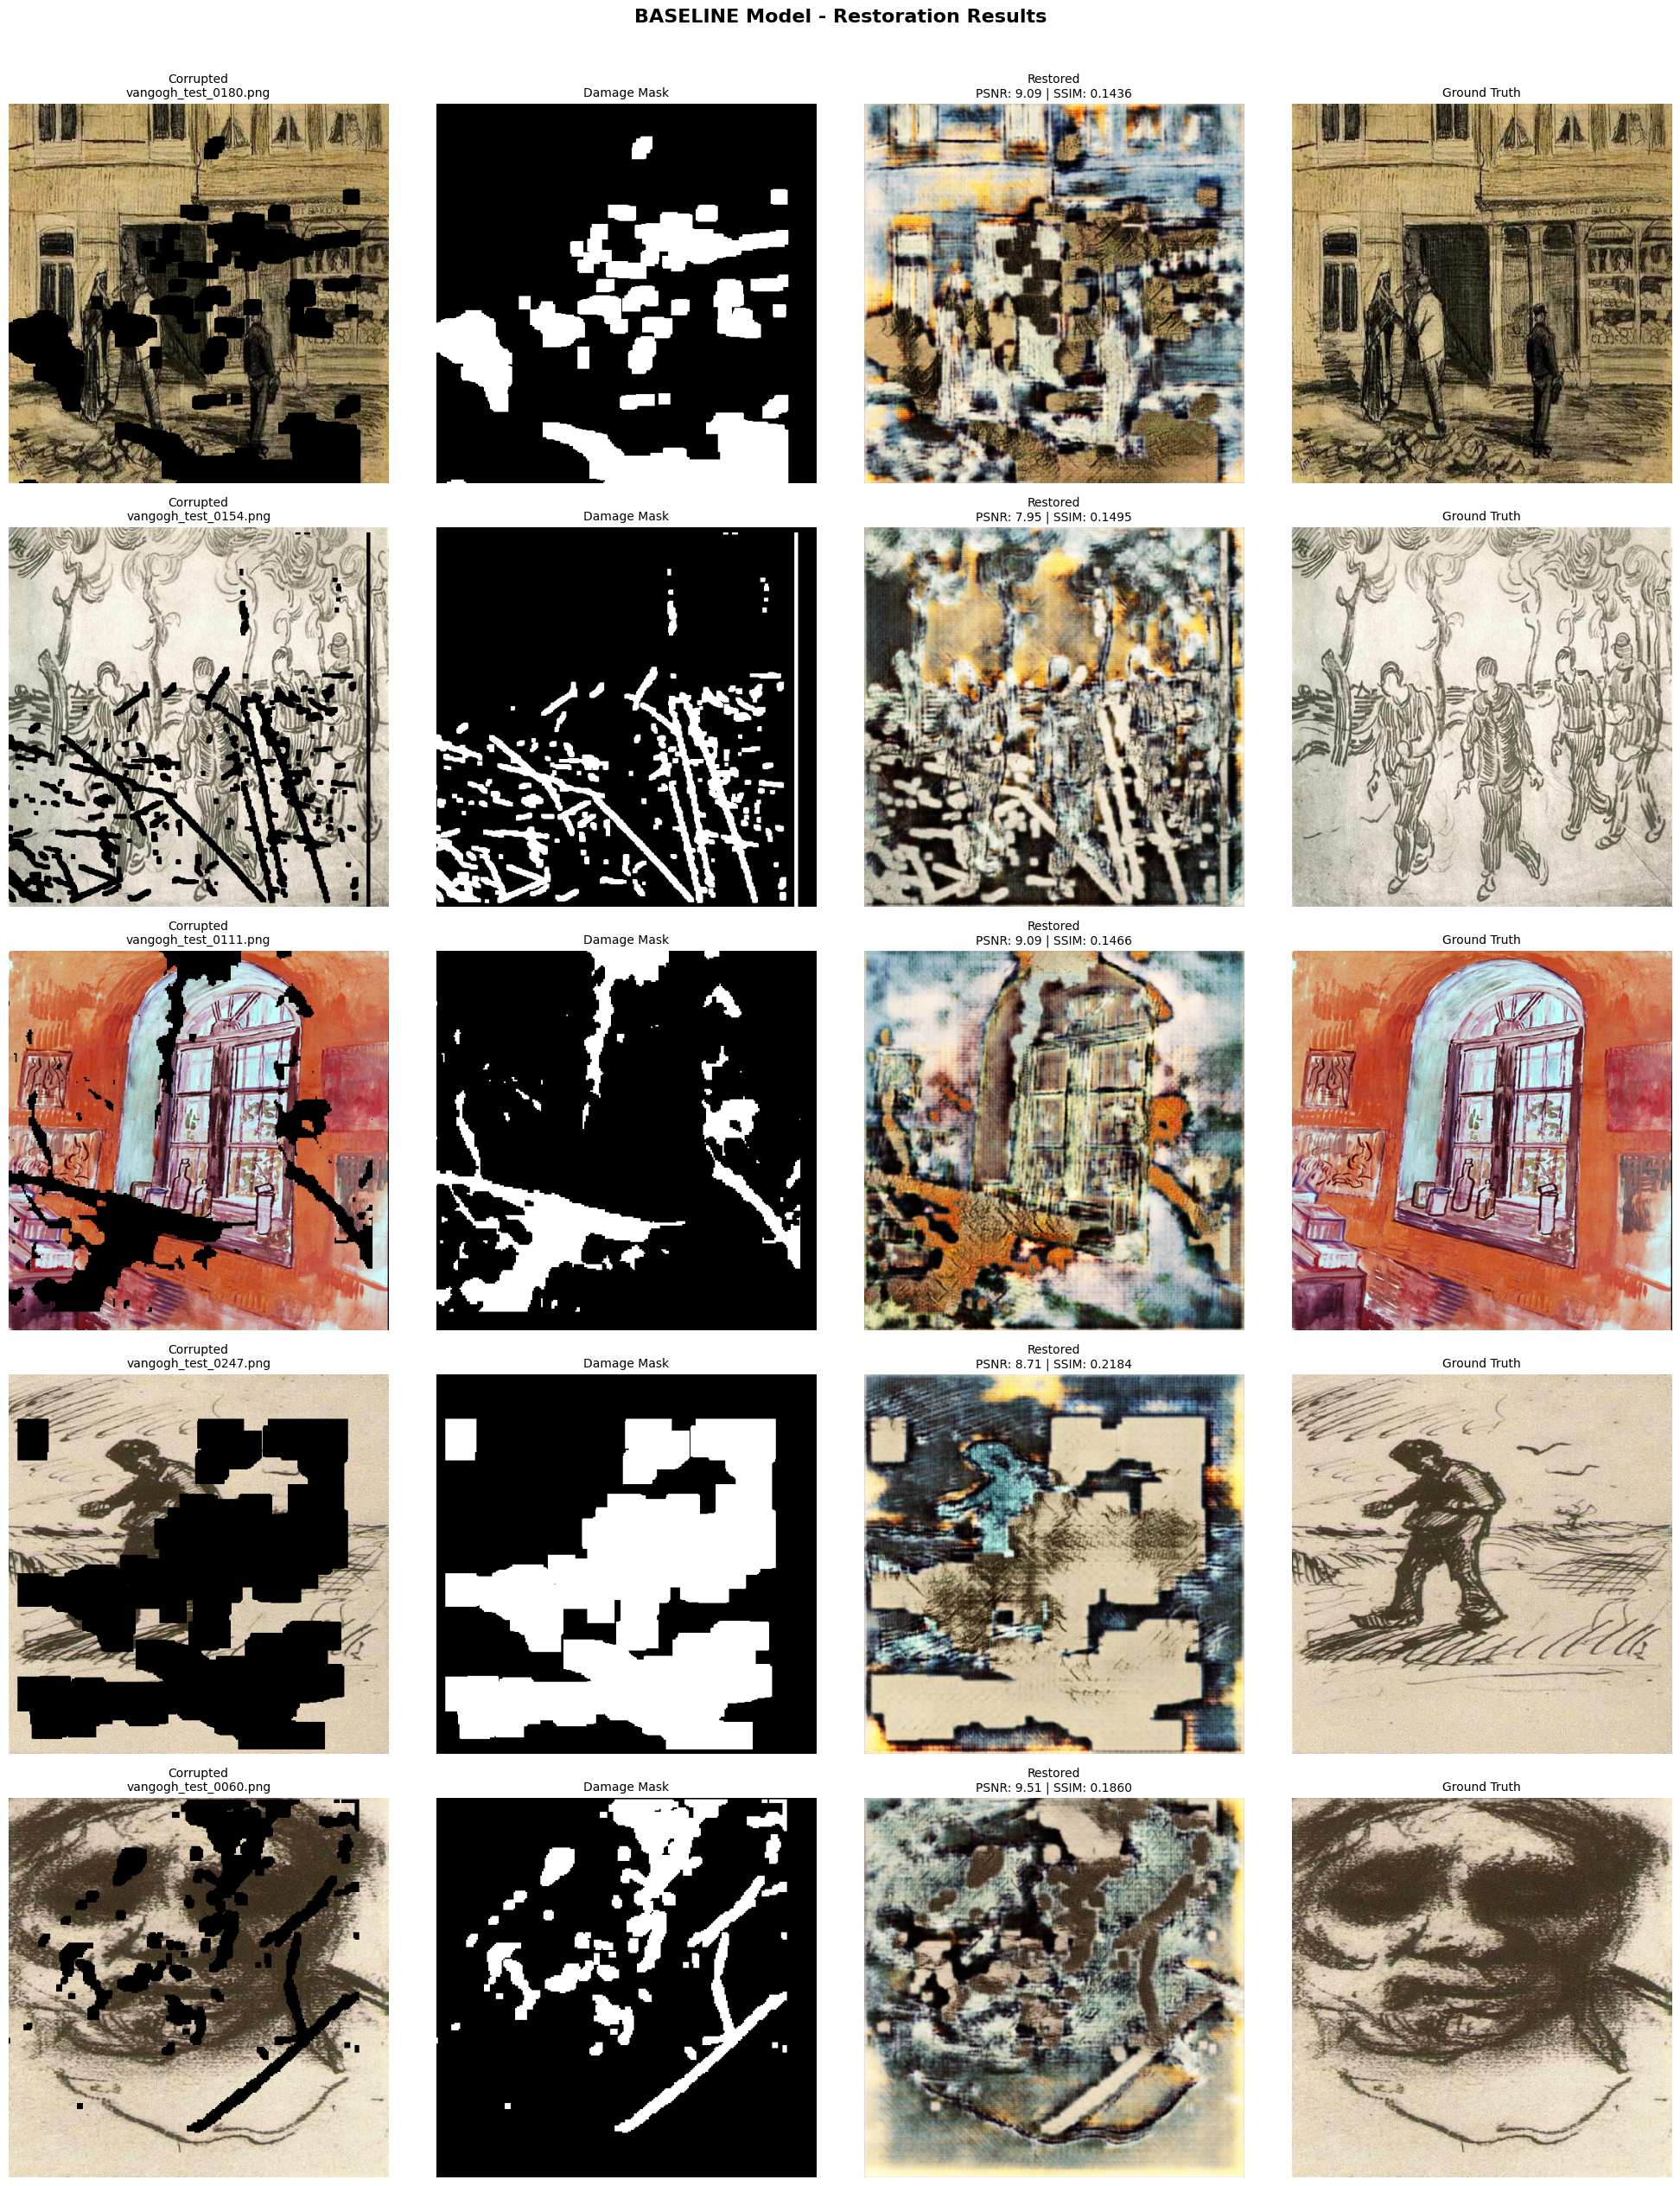

In [24]:
# ============================================================================
# 14. VISUALIZE RESULTS
# ============================================================================

def visualize_results(generator, dataset, num_samples=5, save_dir=None):
    """Visualize restoration results: corrupted → restored → original"""
    
    generator.eval()
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    if num_samples == 1:
        axes = axes[np.newaxis, :]
    
    with torch.no_grad():
        for row, idx in enumerate(indices):
            sample = dataset[idx]
            corrupted = sample['corrupted'].unsqueeze(0).to(device)
            mask = sample['mask'].unsqueeze(0).to(device)
            original = sample['original'].unsqueeze(0).to(device)
            img_name = sample['image_name']
            
            restored = generator(corrupted, mask)
            
            # Convert to numpy for display
            corrupted_np = corrupted[0].cpu().numpy().transpose(1, 2, 0)
            mask_np = mask[0].cpu().numpy().squeeze()
            restored_np = restored[0].cpu().numpy().transpose(1, 2, 0)
            original_np = original[0].cpu().numpy().transpose(1, 2, 0)
            
            corrupted_np = np.clip(corrupted_np, 0, 1)
            restored_np = np.clip(restored_np, 0, 1)
            original_np = np.clip(original_np, 0, 1)
            
            # Calculate per-image metrics
            psnr_val = calculate_psnr(restored[0], original[0])
            ssim_val = calculate_ssim(restored[0], original[0])
            
            # Plot
            axes[row, 0].imshow(corrupted_np)
            axes[row, 0].set_title(f'Corrupted\n{img_name}', fontsize=10)
            axes[row, 0].axis('off')
            
            axes[row, 1].imshow(mask_np, cmap='gray')
            axes[row, 1].set_title('Damage Mask', fontsize=10)
            axes[row, 1].axis('off')
            
            axes[row, 2].imshow(restored_np)
            axes[row, 2].set_title(f'Restored\nPSNR: {psnr_val:.2f} | SSIM: {ssim_val:.4f}', fontsize=10)
            axes[row, 2].axis('off')
            
            axes[row, 3].imshow(original_np)
            axes[row, 3].set_title('Ground Truth', fontsize=10)
            axes[row, 3].axis('off')
            
    
    plt.suptitle(f'{CONFIG["model_type"].upper()} Model - Restoration Results', 
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    
    if save_dir:
        save_path = os.path.join(save_dir, f'{CONFIG["model_type"]}_visual_results.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Visualization saved to: {save_path}")
    
    plt.show()


# Visualize on test set
test_dataset = VanGoghDataset(
    CONFIG['test_original_dir'], CONFIG['test_masked_dir'],
    CONFIG['test_masks_dir'], CONFIG['brushstroke_h5'], split='test'
)

output_dir = os.path.join('results', 'outputs', CONFIG['model_type'])
visualize_results(generator, test_dataset, num_samples=5, save_dir=output_dir)


In [ ]:
# # ============================================================================
# # 15. PLOT TRAINING CURVES FROM SAVED HISTORY (works if run stopped early)
# # ============================================================================
# import matplotlib.pyplot as plt

# def load_saved_training_history(config):
#     """Load final history if present, otherwise live history."""
#     candidate_paths = [config.get('history_final_json'), config.get('history_live_json')]
#     for p in candidate_paths:
#         if p and os.path.exists(p):
#             with open(p, 'r') as f:
#                 payload = json.load(f)
#             print(f"Loaded history: {p}")
#             return payload, p
#     raise FileNotFoundError(
#         "No saved history JSON found. Expected one of:\n"
#         f"  - {config.get('history_final_json')}\n"
#         f"  - {config.get('history_live_json')}"
#     )

# def plot_saved_training_history(config, show=True):
#     payload, path = load_saved_training_history(config)

#     train_history = payload.get('train_history', [])
#     val_history = payload.get('val_history', [])
#     status = payload.get('status', 'unknown')
#     epochs_planned = int(payload.get('epochs_planned', config.get('epochs', 0)))
#     best_val_loss = payload.get('best_val_loss', None)

#     if len(train_history) == 0 and len(val_history) == 0:
#         print("History file exists but contains no epochs yet.")
#         return payload

#     epochs_train = np.arange(1, len(train_history) + 1)
#     epochs_val = np.arange(1, len(val_history) + 1)

#     def pick(series, key):
#         return np.array([float(d.get(key, np.nan)) for d in series], dtype=np.float32)

#     fig = plt.figure(figsize=(14, 10))

#     ax1 = fig.add_subplot(2, 2, 1)
#     if len(train_history):
#         if 'g_total' in train_history[0]:
#             ax1.plot(epochs_train, pick(train_history, 'g_total'), label='Train G Total')
#         if 'g_total_raw' in train_history[0]:
#             ax1.plot(epochs_train, pick(train_history, 'g_total_raw'), label='Train G Raw', alpha=0.6)
#     if len(val_history):
#         if 'total' in val_history[0]:
#             ax1.plot(epochs_val, pick(val_history, 'total'), label='Val Total')
#     ax1.set_title('Main Loss Curves')
#     ax1.set_xlabel('Epoch')
#     ax1.set_ylabel('Loss')
#     ax1.legend()
#     ax1.grid(True, alpha=0.3)

#     ax2 = fig.add_subplot(2, 2, 2)
#     if len(train_history):
#         if 'd_global' in train_history[0]:
#             ax2.plot(epochs_train, pick(train_history, 'd_global'), label='D Global')
#         if 'd_local' in train_history[0]:
#             ax2.plot(epochs_train, pick(train_history, 'd_local'), label='D Local')
#     ax2.set_title('Discriminator Losses')
#     ax2.set_xlabel('Epoch')
#     ax2.set_ylabel('Loss')
#     ax2.legend()
#     ax2.grid(True, alpha=0.3)

#     ax3 = fig.add_subplot(2, 2, 3)
#     if len(train_history):
#         for k in ['l1', 'perceptual', 'style', 'adv_global', 'adv_local']:
#             if k in train_history[0]:
#                 ax3.plot(epochs_train, pick(train_history, k), label=k)
#     ax3.set_title('Standard Loss Components (Train)')
#     ax3.set_xlabel('Epoch')
#     ax3.set_ylabel('Loss')
#     ax3.legend(fontsize=8)
#     ax3.grid(True, alpha=0.3)

#     ax4 = fig.add_subplot(2, 2, 4)
#     if len(train_history):
#         for k in ['direction', 'edge_strength', 'histogram']:
#             if k in train_history[0]:
#                 ax4.plot(epochs_train, pick(train_history, k), label=k)
#     ax4.set_title('Brushstroke Loss Components (Train)')
#     ax4.set_xlabel('Epoch')
#     ax4.set_ylabel('Loss')
#     ax4.legend(fontsize=8)
#     ax4.grid(True, alpha=0.3)

#     completed = max(len(train_history), len(val_history))
#     title = f"Training Curves [{status}]  {completed}/{epochs_planned} epochs"
#     if best_val_loss is not None:
#         try:
#             title += f"  |  best val={float(best_val_loss):.4f}"
#         except Exception:
#             pass
#     fig.suptitle(title, fontsize=14)
#     fig.tight_layout()

#     # Save a report plot
#     out_plot = os.path.join(CONFIG['output_dir'], 'training_curves_report.png')
#     fig.savefig(out_plot, dpi=150, bbox_inches='tight')

#     if show:
#         plt.show()
#     else:
#         plt.close(fig)

#     print(f"Saved report plot: {out_plot}")
#     print(f"History source: {path}")
#     return payload

# # Run plot loader (safe for fully trained or interrupted runs)
# history_payload = plot_saved_training_history(CONFIG, show=True)

In [25]:
# ============================================================================
# 16. SINGLE IMAGE INFERENCE
# ============================================================================

def infer_single_image(generator, image_path, mask_path, output_path=None):
    """
    Run inference on a single image
    
    Args:
        generator: Trained generator model
        image_path: Path to the corrupted/damaged image
        mask_path: Path to the damage mask (white = damaged region)
        output_path: Optional path to save the restored image
    
    Returns:
        restored_image: Restored image as numpy array (H, W, 3)
    """
    generator.eval()
    
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor()
    ])
    
    # Load and preprocess
    corrupted = Image.open(image_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')
    
    original_size = corrupted.size  # (W, H)
    
    corrupted_tensor = transform(corrupted).unsqueeze(0).to(device)
    mask_tensor = transform(mask).unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        restored_tensor = generator(corrupted_tensor, mask_tensor)
    
    # Convert to numpy
    restored_np = restored_tensor[0].cpu().numpy().transpose(1, 2, 0)
    restored_np = np.clip(restored_np, 0, 1)
    
    # Resize back to original size
    restored_pil = Image.fromarray((restored_np * 255).astype(np.uint8))
    restored_pil = restored_pil.resize(original_size, Image.LANCZOS)
    
    # Save if path provided
    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        restored_pil.save(output_path)
        print(f"✓ Restored image saved to: {output_path}")
    
    # Display
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(Image.open(image_path).convert('RGB'))
    axes[0].set_title('Corrupted Input')
    axes[0].axis('off')
    
    axes[1].imshow(Image.open(mask_path).convert('L'), cmap='gray')
    axes[1].set_title('Damage Mask')
    axes[1].axis('off')
    
    axes[2].imshow(restored_pil)
    axes[2].set_title('Restored Output')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    
    return np.array(restored_pil)


# Example usage (uncomment and update paths):
# restored = infer_single_image(
#     generator,
#     image_path='path/to/corrupted_image.png',
#     mask_path='path/to/mask.png',
#     output_path='results/outputs/restored_image.png'
# )
print("✓ Single image inference function ready")


✓ Single image inference function ready


In [26]:
# ============================================================================
# 17. BATCH INFERENCE ON TEST SET (Save All Restored Images)
# ============================================================================

def batch_inference(generator, config, output_dir='results/outputs/restored'):
    """Run inference on entire test set and save all restored images"""
    
    os.makedirs(output_dir, exist_ok=True)
    
    test_dataset = VanGoghDataset(
        config['test_original_dir'], config['test_masked_dir'],
        config['test_masks_dir'], config['brushstroke_h5'], split='test'
    )
    testloader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)
    
    generator.eval()
    
    print(f"\nSaving restored images to: {output_dir}")
    
    with torch.no_grad():
        for batch in tqdm(testloader, desc="Restoring"):
            corrupted = batch['corrupted'].to(device)
            mask = batch['mask'].to(device)
            img_name = batch['image_name'][0]
            
            restored = generator(corrupted, mask)
            
            # Save restored image
            restored_np = restored[0].cpu().numpy().transpose(1, 2, 0)
            restored_np = np.clip(restored_np * 255, 0, 255).astype(np.uint8)
            restored_pil = Image.fromarray(restored_np)
            restored_pil.save(os.path.join(output_dir, img_name))
            
    
    print(f"✓ All {len(test_dataset)} restored images saved to: {output_dir}")


# Run batch inference
output_dir = os.path.join('results', 'outputs', CONFIG['model_type'], 'restored_images')
batch_inference(generator, CONFIG, output_dir=output_dir)


TEST dataset: 305 images (lazy H5 read)

Saving restored images to: results/outputs/baseline/restored_images


Restoring: 100%|██████████████████████████████| 305/305 [01:04<00:00,  4.71it/s]

✓ All 305 restored images saved to: results/outputs/baseline/restored_images


In [ ]:
# ============================================================================
# 18. COMPARISON: BASELINE vs FULL MODEL
# ============================================================================

def compare_models(baseline_path, full_model_path, config):
    """
    Compare baseline and full model side by side
    Loads both models and evaluates on test set
    """
    
    test_dataset = VanGoghDataset(
        config['test_original_dir'], config['test_masked_dir'],
        config['test_masks_dir'], config['brushstroke_h5'], split='test'
    )
    
    # Initialize two generators
    gen_baseline = SGRGANGenerator(in_channels=4, out_channels=3).to(device)
    gen_full = SGRGANGenerator(in_channels=4, out_channels=3).to(device)
    
    models_loaded = {'baseline': False, 'full': False}
    
    # Load baseline
    if os.path.exists(baseline_path):
        ckpt = torch.load(baseline_path, map_location=device)
        gen_baseline.load_state_dict(ckpt['generator_state_dict'])
        gen_baseline.eval()
        models_loaded['baseline'] = True
        print(f"✓ Baseline loaded (epoch {ckpt['epoch'] + 1})")
    else:
        print(f"⚠ Baseline not found at {baseline_path}")
    
    # Load full model
    if os.path.exists(full_model_path):
        ckpt = torch.load(full_model_path, map_location=device)
        gen_full.load_state_dict(ckpt['generator_state_dict'])
        gen_full.eval()
        models_loaded['full'] = True
        print(f"✓ Full model loaded (epoch {ckpt['epoch'] + 1})")
    else:
        print(f"⚠ Full model not found at {full_model_path}")
    
    if not all(models_loaded.values()):
        print("⚠ Cannot compare - both models must be available")
        return
    
    # Compare on random samples
    num_samples = 4
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    
    baseline_psnrs, full_psnrs = [], []
    baseline_ssims, full_ssims = [], []
    
    with torch.no_grad():
        for row, idx in enumerate(indices):
            sample = test_dataset[idx]
            corrupted = sample['corrupted'].unsqueeze(0).to(device)
            mask = sample['mask'].unsqueeze(0).to(device)
            original = sample['original'].unsqueeze(0).to(device)
            
            restored_base = gen_baseline(corrupted, mask)
            restored_full = gen_full(corrupted, mask)
            
            # Metrics
            psnr_base = calculate_psnr(restored_base[0], original[0])
            psnr_full = calculate_psnr(restored_full[0], original[0])
            ssim_base = calculate_ssim(restored_base[0], original[0])
            ssim_full = calculate_ssim(restored_full[0], original[0])
            
            baseline_psnrs.append(psnr_base)
            full_psnrs.append(psnr_full)
            baseline_ssims.append(ssim_base)
            full_ssims.append(ssim_full)
            
            # Plot
            axes[row, 0].imshow(corrupted[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1))
            axes[row, 0].set_title('Corrupted', fontsize=11)
            axes[row, 0].axis('off')
            
            axes[row, 1].imshow(restored_base[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1))
            axes[row, 1].set_title(f'Baseline\nPSNR: {psnr_base:.2f} | SSIM: {ssim_base:.4f}', fontsize=10)
            axes[row, 1].axis('off')
            
            axes[row, 2].imshow(restored_full[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1))
            axes[row, 2].set_title(f'Full (+ Brushstroke)\nPSNR: {psnr_full:.2f} | SSIM: {ssim_full:.4f}', fontsize=10)
            axes[row, 2].axis('off')
            
            axes[row, 3].imshow(original[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1))
            axes[row, 3].set_title('Ground Truth', fontsize=11)
            axes[row, 3].axis('off')
            
    
    plt.suptitle('Baseline vs Full Model (with Brushstroke Losses)', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('results/outputs/model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Summary
    print(f"\n{'='*50}")
    print(f"COMPARISON SUMMARY ({num_samples} samples)")
    print(f"{'='*50}")
    print(f"  Baseline  - Avg PSNR: {np.mean(baseline_psnrs):.2f} dB | Avg SSIM: {np.mean(baseline_ssims):.4f}")
    print(f"  Full Model - Avg PSNR: {np.mean(full_psnrs):.2f} dB | Avg SSIM: {np.mean(full_ssims):.4f}")
    psnr_diff = np.mean(full_psnrs) - np.mean(baseline_psnrs)
    ssim_diff = np.mean(full_ssims) - np.mean(baseline_ssims)
    print(f"  Improvement: PSNR {psnr_diff:+.2f} dB | SSIM {ssim_diff:+.4f}")
    print(f"{'='*50}")
    
    del gen_baseline, gen_full


# Compare models (uncomment when both models are trained)
baseline_path = 'models/baseline/baseline_best.pth'
full_model_path = 'models/full_model/full_best.pth'

if os.path.exists(baseline_path) and os.path.exists(full_model_path):
    compare_models(baseline_path, full_model_path, CONFIG)
else:
    print("⚠ Both baseline and full model must be trained before comparison")
    print(f"  Baseline exists: {os.path.exists(baseline_path)}")
    print(f"  Full model exists: {os.path.exists(full_model_path)}")


In [ ]:
# ============================================================================
# 19. BRUSHSTROKE ANALYSIS VISUALIZATION (FIXED: new API + composition)
# ============================================================================

def visualize_brushstroke_analysis(generator, dataset, num_samples=3):
    """Visualize brushstroke orientation and edge-strength for restored vs GT."""
    generator.eval()
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    fig, axes = plt.subplots(num_samples, 5, figsize=(25, 5 * num_samples))
    if num_samples == 1:
        axes = axes[np.newaxis, :]

    with torch.no_grad():
        for row, idx in enumerate(indices):
            sample = dataset[idx]
            corrupted = sample["corrupted"].unsqueeze(0).to(device)
            mask = sample["mask"].unsqueeze(0).to(device)
            original = sample["original"].unsqueeze(0).to(device)
            gt_orient = sample["orientation_field"].unsqueeze(0).to(device)
            gt_edge = sample["edge_strength_map"].unsqueeze(0).to(device)

            restored = generator(corrupted, mask)
            comp = corrupted * (1 - mask) + restored * mask

            pred_orient = brushstroke_losses._extract_orientation(comp)
            pred_edge = brushstroke_losses._sobel_magnitude(comp)

            comp_np = comp[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1)
            orig_np = original[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1)
            pred_orient_np = pred_orient[0, 0].cpu().numpy()
            if gt_orient.shape[1] > 1:
                gt_orient_np = gt_orient[0].argmax(dim=0).cpu().numpy() * 22.5
            else:
                gt_orient_np = gt_orient[0, 0].cpu().numpy()
            pred_edge_np = pred_edge[0, 0].cpu().numpy()

            axes[row, 0].imshow(comp_np)
            axes[row, 0].set_title("Restored (composed)", fontsize=11)
            axes[row, 0].axis("off")
            axes[row, 1].imshow(orig_np)
            axes[row, 1].set_title("Ground Truth", fontsize=11)
            axes[row, 1].axis("off")
            axes[row, 2].imshow(pred_orient_np, cmap="hsv", vmin=0, vmax=180)
            axes[row, 2].set_title("Pred Orientation", fontsize=11)
            axes[row, 2].axis("off")
            axes[row, 3].imshow(gt_orient_np, cmap="hsv", vmin=0, vmax=180)
            axes[row, 3].set_title("GT Orientation", fontsize=11)
            axes[row, 3].axis("off")
            axes[row, 4].imshow(pred_edge_np, cmap="hot")
            axes[row, 4].set_title("Pred Edge Strength", fontsize=11)
            axes[row, 4].axis("off")

    plt.suptitle("Brushstroke Analysis", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    out_path = os.path.join(CONFIG["output_dir"], "brushstroke_analysis.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to: {out_path}")

visualize_brushstroke_analysis(generator, test_dataset, num_samples=3)


In [ ]:
# ============================================================================
# 20. EXPORT MODEL FOR DEPLOYMENT
# ============================================================================

def export_model(generator, config, export_path='models/exported'):
    """Export trained model for deployment/sharing"""
    
    os.makedirs(export_path, exist_ok=True)
    
    # 1. Save generator weights only (smaller file)
    weights_path = os.path.join(export_path, f'{config["model_type"]}_generator_weights.pth')
    torch.save(generator.state_dict(), weights_path)
    file_size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    print(f"✓ Generator weights saved: {weights_path} ({file_size_mb:.1f} MB)")
    
    # 2. Save full model with config for reproducibility
    full_path = os.path.join(export_path, f'{config["model_type"]}_full_export.pth')
    torch.save({
        'generator_state_dict': generator.state_dict(),
        'config': config,
        'model_architecture': 'SGRGANGenerator',
        'input_channels': 4,
        'output_channels': 3,
        'image_size': config['image_size'],
    }, full_path)
    file_size_mb = os.path.getsize(full_path) / (1024 * 1024)
    print(f"✓ Full export saved: {full_path} ({file_size_mb:.1f} MB)")
    
    # 3. Model summary
    total_params = sum(p.numel() for p in generator.parameters())
    trainable_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
    print(f"\nModel Summary:")
    print(f"  Architecture: SGRGANGenerator (BiSCCFormer + Focal)")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"  Input: (B, 4, 512, 512) [corrupted RGB + mask]")
    print(f"  Output: (B, 3, 512, 512) [restored RGB]")
    print(f"  Model type: {config['model_type']}")


# Export the model
export_model(generator, CONFIG)

print("\n" + "=" * 80)
print("🎨 PIPELINE COMPLETE")
print("=" * 80)
print("All cells executed successfully. Summary of outputs:")
print("  • Cell 12: Evaluation metrics (PSNR, SSIM, L1, L2)")
print("  • Cell 13: Test set evaluation with per-image metrics")
print("  • Cell 14: Visual comparison (corrupted → restored → ground truth)")
print("  • Cell 15: Training history plots")
print("  • Cell 16: Single image inference function")
print("  • Cell 17: Batch inference on full test set")
print("  • Cell 18: Baseline vs Full model comparison")
print("  • Cell 19: Brushstroke direction & thickness analysis")
print("  • Cell 20: Model export for deployment")
print("=" * 80)

In [ ]:
# ============================================================================
# ABLATION RUNNER
# Trains based on CONFIG['model_type'] and saves to run folder.
# Each ablation writes to its own timestamped directory.
# ============================================================================

def run_ablation(ablation_name):
    """Run a single ablation from scratch.
    Returns fresh (gen, dg, dl). Caller assigns them to module-level variables.
    """
    global generator, disc_global, disc_local
    print(f'\n{"="*80}')
    print(f'ABLATION: {ablation_name.upper()}')
    print(f'{"="*80}')

    # Re-seed for fair comparison
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Apply ablation config
    for k, v in ABLATION_CONFIGS[ablation_name].items():
        CONFIG[k] = v
    CONFIG['model_type'] = ablation_name

    # Create run-specific dirs
    import datetime
    tag = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    CONFIG['run_tag'] = tag
    base = str(RUNS_ROOT / f"{ablation_name}_{tag}")
    CONFIG['checkpoint_dir'] = f'{base}/checkpoints'
    CONFIG['log_dir'] = f'{base}/logs'
    CONFIG['output_dir'] = f'{base}/outputs'
    for d in [CONFIG['checkpoint_dir'], CONFIG['log_dir'], CONFIG['output_dir']]:
        os.makedirs(d, exist_ok=True)

    # Re-derive history paths (train_full_model depends on these)
    CONFIG['history_live_json']  = os.path.join(CONFIG['log_dir'], 'training_history_live.json')
    CONFIG['history_final_json'] = os.path.join(CONFIG['log_dir'], 'training_history_final.json')
    CONFIG['history_csv']        = os.path.join(CONFIG['log_dir'], 'training_history_live.csv')
    CONFIG['history_plot_png']   = os.path.join(CONFIG['output_dir'], 'training_curves_live.png')

    # Save config snapshot
    with open(os.path.join(CONFIG['log_dir'], 'config_snapshot.json'), 'w') as f:
        json.dump(CONFIG, f, indent=2)

    # Re-init model weights
    gen = SGRGANGenerator(in_channels=4, out_channels=3).to(device)
    dg = GlobalDiscriminator(in_channels=3).to(device)
    dl = LocalDiscriminator(in_channels=3).to(device)

    # Compile ablation models (speed only; safe to skip if unsupported)
    try:
        gen = torch.compile(gen)
        dg  = torch.compile(dg)
        dl  = torch.compile(dl)
        print("✓ Compiled ablation models")
    except Exception as e:
        print(f"torch.compile skipped in ablation: {e}")

    print(f'  Lambda dir={CONFIG["lambda_direction"]}, edge={CONFIG["lambda_thickness"]}, hist={CONFIG["lambda_histogram"]}')
    print(f'  Run dir: {base}')
    print(f'  Config saved. Ready to train -- call train_full_model().')
    return gen, dg, dl

# Usage:
# generator, disc_global, disc_local = run_ablation('baseline')
# train_history, val_history = train_full_model()
# all_metrics, avg_metrics = evaluate_on_test_set(generator, CONFIG)
print('Ablation runner loaded.')
print('  Usage: generator, disc_global, disc_local = run_ablation("baseline")')

In [ ]:
# ============================================================================
# VISUAL EVIDENCE FOR THESIS
# 1) 4-column qualitative grid: corrupted | mask | restored | ground truth
# 2) Zoom patches from masked regions
# ============================================================================

import matplotlib.pyplot as plt

def save_qualitative_grid(generator, test_dataset, all_metrics, config):
    """Save best/worst PSNR examples as 4-column grid."""
    psnr_list = all_metrics['psnr']
    sorted_idx = np.argsort(psnr_list)
    worst_idx = sorted_idx[0]
    best_idx = sorted_idx[-1]

    generator.eval()
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    for row, idx in enumerate([best_idx, worst_idx]):
        sample = test_dataset[idx]
        corrupted = sample['corrupted'].unsqueeze(0).to(device)
        mask = sample['mask'].unsqueeze(0).to(device)
        original = sample['original'].unsqueeze(0).to(device)

        with torch.no_grad():
            restored = generator(corrupted, mask)
            comp = corrupted * (1 - mask) + restored * mask

        c_np = corrupted[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1)
        m_np = mask[0, 0].cpu().numpy()
        r_np = comp[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1)
        g_np = original[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1)

        label = 'Best PSNR' if row == 0 else 'Worst PSNR'
        psnr_val = psnr_list[idx]

        axes[row, 0].imshow(c_np)
        axes[row, 0].set_title('Corrupted', fontsize=12)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(m_np, cmap='gray')
        axes[row, 1].set_title('Mask', fontsize=12)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(r_np)
        axes[row, 2].set_title(f'Restored ({label})\nPSNR={psnr_val:.2f}', fontsize=12)
        axes[row, 2].axis('off')

        axes[row, 3].imshow(g_np)
        axes[row, 3].set_title('Ground Truth', fontsize=12)
        axes[row, 3].axis('off')


    plt.suptitle(f'Qualitative Results [{config["model_type"].upper()}]',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    grid_path = os.path.join(config['output_dir'], 'qualitative_grid.png')
    plt.savefig(grid_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved qualitative grid to: {grid_path}')


def save_zoom_patches(generator, test_dataset, all_metrics, config, crop_size=128):
    """Save zoom crops from masked region: best and worst PSNR."""
    out_dir = os.path.join(config['output_dir'], 'zoom_patches')
    os.makedirs(out_dir, exist_ok=True)

    psnr_list = all_metrics['psnr']
    sorted_idx = np.argsort(psnr_list)
    best_idx, worst_idx = sorted_idx[-1], sorted_idx[0]

    generator.eval()

    for label, idx in [('best', best_idx), ('worst', worst_idx)]:
        sample = test_dataset[idx]
        corrupted = sample['corrupted'].unsqueeze(0).to(device)
        mask = sample['mask'].unsqueeze(0).to(device)
        original = sample['original'].unsqueeze(0).to(device)
        name = sample['image_name']

        with torch.no_grad():
            restored = generator(corrupted, mask)
            comp = corrupted * (1 - mask) + restored * mask

        r_np = comp[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1)
        g_np = original[0].cpu().numpy().transpose(1, 2, 0).clip(0, 1)
        m_np = mask[0, 0].cpu().numpy()

        # Find masked region centroid
        ys, xs = np.where(m_np > 0.5)
        if len(ys) == 0:
            continue
        cy, cx = int(ys.mean()), int(xs.mean())
        h2 = crop_size // 2
        y1 = max(0, cy - h2)
        x1 = max(0, cx - h2)
        y2 = min(512, y1 + crop_size)
        x2 = min(512, x1 + crop_size)

        crop_r = r_np[y1:y2, x1:x2]
        crop_g = g_np[y1:y2, x1:x2]

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(crop_r)
        axes[0].set_title('Restored (zoom)', fontsize=11)
        axes[0].axis('off')
        axes[1].imshow(crop_g)
        axes[1].set_title('Ground Truth (zoom)', fontsize=11)
        axes[1].axis('off')
        plt.suptitle(f'{label.upper()} PSNR - {name}', fontsize=12)
        plt.tight_layout()
        save_path = os.path.join(out_dir, f'zoom_{label}_{name}')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  Saved zoom: {save_path}')



# Usage (after evaluation):
# save_qualitative_grid(generator, test_dataset, all_metrics, CONFIG)
# save_zoom_patches(generator, test_dataset, all_metrics, CONFIG)
print('Visual evidence functions loaded.')
print('  Call save_qualitative_grid() and save_zoom_patches() after evaluation.')
